# Estrategias atribuidas a Alejandro Cardona — Notebook multi‑activo

Este notebook convierte en reglas programables el resumen incluido en el PDF adjunto:

- **Gap bajista al alza → CALL**
- **Ruptura del canal bajista → CALL**
- **Primera vela roja de apertura → PUT**
- **PUT dentro de canal bajista**
- **Piso fuerte MA100/MA200 + ruptura horaria → CALL**
- **Ruptura del piso del gap → PUT**
- Revisión de medias móviles **20, 40, 100 y 200**
- Primera vela horaria configurable; por defecto **10:00–11:00 ET**
- Riesgo configurable entre **1 % y 3 %** por operación
- Vencimiento sugerido: misma semana de lunes a miércoles; semana siguiente jueves o viernes

> **Alcance importante:** el PDF es un resumen de reglas atribuidas al educador, no una especificación matemática oficial. Los conceptos discrecionales —por ejemplo, “canal bajista”, “piso fuerte” o “confirmación”— se convierten aquí en definiciones cuantitativas configurables.

> **Backtest:** mide el movimiento direccional del **activo subyacente**, no el rendimiento real de una opción. Para reproducir CALL/PUT de forma exacta harían falta primas históricas, strike, delta, volatilidad implícita, spread y vencimiento de cada contrato.

Este material es educativo y no constituye asesoría financiera.


In [1]:
# Ejecuta esta celda una sola vez en Google Colab o en un entorno nuevo.
%pip install -q yfinance pandas numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


## 1. Importaciones y configuración

Yahoo Finance usa estos símbolos, entre otros:

| Activo | Símbolo |
|---|---|
| Oro futuro | `GC=F` |
| Plata futuro | `SI=F` |
| EUR/USD | `EURUSD=X` |
| Bitcoin | `BTC-USD` |
| Ethereum | `ETH-USD` |
| Tesla | `TSLA` |
| Apple | `AAPL` |
| S&P 500 ETF | `SPY` |
| Nasdaq 100 ETF | `QQQ` |
| TRON | `ThetherUS` |

También puedes escribir directamente cualquier ticker reconocido por Yahoo Finance.


In [2]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Dict, Optional, Tuple, List
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Paleta compartida por las 4 gráficas del notebook (secciones 7 y 10).
# Verde = objetivo/profit, CALL (compra) y operación ganadora.
# Rojo  = stop loss, drawdown, PUT (venta) y operación perdedora.
# La dirección/resultado nunca dependen solo del color: cada marca añade
# además una forma distinta (▲/▼), un trazo distinto o una etiqueta de texto.
ZONE_COLOR_GOOD = "#0ca30c"
ZONE_COLOR_CRITICAL = "#d03b3b"
PRICE_COLOR = "#2a78d6"
GRID_COLOR = "#898781"

ASSETS: Dict[str, Dict[str, object]] = {
    "ORO":       {"ticker": "GC=F",     "clase": "Futuro",     "opciones": True},
    "PLATA":     {"ticker": "SI=F",     "clase": "Futuro",     "opciones": True},
    "EUR_USD":   {"ticker": "EURUSD=X", "clase": "Forex",      "opciones": False},
    "BTC":       {"ticker": "BTC-USD",  "clase": "Cripto",     "opciones": False},
    "ETH":       {"ticker": "ETH-USD",  "clase": "Cripto",     "opciones": False},
    "TESLA":     {"ticker": "TSLA",     "clase": "Acción",     "opciones": True},
    "APPLE":     {"ticker": "AAPL",     "clase": "Acción",     "opciones": True},
    "SPY":       {"ticker": "SPY",      "clase": "ETF",        "opciones": True},
    "QQQ":       {"ticker": "QQQ",      "clase": "ETF",        "opciones": True},
    "TRON":       {"ticker": "TRX-USD",  "clase": "Cripto",     "opciones": False},
}

@dataclass
class StrategyConfig:
    # Activo: usa una clave de ASSETS o un ticker directo.
    asset: str = "SPY"
    custom_ticker: Optional[str] = None

    # Datos
    daily_period: str = "2y"
    intraday_period: str = "60d"
    raw_intraday_interval: str = "30m"
    timezone: str = "America/New_York"

    # Primera vela definida en el PDF: 10:00–11:00 ET
    first_candle_hour: int = 10

    # Medias y canales
    ma_windows: Tuple[int, ...] = (20, 40, 100, 200)
    hourly_channel_lookback: int = 30
    channel_breakout_tolerance: float = 0.001
    gap_threshold: float = 0.001
    strong_floor_tolerance: float = 0.012
    floor_memory_bars: int = 6
    channel_put_min_position: float = 0.55

    # Backtest del subyacente: extensión cuantitativa, no regla literal del PDF
    initial_capital: float = 10_000.0
    risk_per_trade: float = 0.02
    atr_window: int = 14
    stop_atr: float = 1.5
    target_atr: float = 2.5
    max_hold_bars: int = 8
    exit_on_opposite_candle: bool = True
    max_notional_multiple: float = 1.0
    cost_bps_per_side: float = 2.0

    def __post_init__(self) -> None:
        if not 0.01 <= self.risk_per_trade <= 0.03:
            raise ValueError("risk_per_trade debe estar entre 0.01 y 0.03.")
        if not 0 <= self.first_candle_hour <= 23:
            raise ValueError("first_candle_hour debe estar entre 0 y 23.")
        if self.hourly_channel_lookback < 10:
            raise ValueError("hourly_channel_lookback debe ser al menos 10.")

    @property
    def ticker(self) -> str:
        if self.custom_ticker:
            return self.custom_ticker.strip().upper()
        key = self.asset.strip().upper()
        return str(ASSETS.get(key, {"ticker": key})["ticker"])

    @property
    def asset_meta(self) -> Dict[str, object]:
        key = self.asset.strip().upper()
        return ASSETS.get(
            key,
            {"ticker": self.ticker, "clase": "Personalizado", "opciones": False},
        )

CFG = StrategyConfig(
    asset="BTC-USD",             # Cambia por ORO, PLATA, EUR_USD, BTC, ETH, TESLA, APPLE...
    custom_ticker=None,      # Ejemplo: "NVDA". Si se usa, reemplaza asset.
    risk_per_trade=0.02,
)

print("Configuración activa:")
display(pd.Series(asdict(CFG), name="valor").to_frame())
print(f"Ticker resuelto: {CFG.ticker}")


Configuración activa:


,valor
asset,BTC-USD
custom_ticker,None
daily_period,2y
intraday_period,60d
raw_intraday_interval,30m
timezone,America/New_York
first_candle_hour,10
ma_windows,"(20, 40, 100, 200)"
hourly_channel_lookback,30
channel_breakout_tolerance,0.001


Ticker resuelto: BTC-USD


## 2. Descarga y preparación de datos

Se descargan:

1. Velas diarias para medias móviles y contexto.
2. Velas de 30 minutos, que se reagrupan a una hora exacta. Así puede construirse la vela **10:00–11:00 ET** de manera consistente.

Los datos intradía de Yahoo Finance tienen una ventana histórica limitada. Si necesitas varios años de velas horarias, sustituye la función de descarga por tu proveedor o bróker.


In [3]:
REQUIRED_OHLC = ["Open", "High", "Low", "Close"]

def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    if isinstance(result.columns, pd.MultiIndex):
        first_level = result.columns.get_level_values(0)
        if set(REQUIRED_OHLC).issubset(set(first_level)):
            result.columns = first_level
        else:
            result.columns = [
                "_".join(str(part) for part in col if str(part) != "")
                for col in result.columns
            ]
    result = result.loc[:, ~result.columns.duplicated()]
    return result

def _validate_ohlc(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = _flatten_columns(df)
    missing = [column for column in REQUIRED_OHLC if column not in df.columns]
    if missing:
        raise ValueError(f"{label}: faltan columnas OHLC: {missing}")
    if "Volume" not in df.columns:
        df["Volume"] = 0.0
    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=REQUIRED_OHLC)
    if df.empty:
        raise ValueError(f"{label}: no se recibieron datos válidos.")
    return df.sort_index()

def _to_market_timezone(df: pd.DataFrame, timezone: str) -> pd.DataFrame:
    result = df.copy()
    index = pd.DatetimeIndex(result.index)
    if index.tz is None:
        index = index.tz_localize("UTC")
    result.index = index.tz_convert(timezone)
    return result

def _download_with_retry(
    label: str,
    max_attempts: int = 4,
    initial_wait: float = 2.0,
    **yf_kwargs,
) -> pd.DataFrame:
    """
    Yahoo Finance a veces responde vacío o incompleto ante solicitudes
    seguidas (por ejemplo, justo después de otra descarga), en especial
    cuando `repair=True` dispara peticiones adicionales de reconstrucción.
    Reintenta con espera creciente antes de rendirse.
    """
    last_error: Optional[Exception] = None
    for attempt in range(1, max_attempts + 1):
        try:
            df = yf.download(**yf_kwargs)
            if df is not None and not df.empty:
                return df
            last_error = ValueError(f"{label}: respuesta vacía de Yahoo Finance.")
        except Exception as exc:  # noqa: BLE001 - se reintenta cualquier fallo de red/parseo
            last_error = exc

        if attempt < max_attempts:
            wait_seconds = initial_wait * (2 ** (attempt - 1))
            print(
                f"{label}: intento {attempt}/{max_attempts} sin datos "
                f"({last_error}). Reintentando en {wait_seconds:.0f}s..."
            )
            time.sleep(wait_seconds)

    raise ValueError(f"{label}: no se pudo descargar tras {max_attempts} intentos ({last_error}).")

def download_market_data(
    ticker: str,
    daily_period: str = "2y",
    intraday_period: str = "60d",
    raw_intraday_interval: str = "30m",
    timezone: str = "America/New_York",
    resample_rule: str = "1h",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    daily = _download_with_retry(
        "Datos diarios",
        tickers=ticker,
        period=daily_period,
        interval="1d",
        auto_adjust=False,
        repair=True,
        progress=False,
        threads=False,
        multi_level_index=False,
    )
    intraday = _download_with_retry(
        "Datos intradía",
        tickers=ticker,
        period=intraday_period,
        interval=raw_intraday_interval,
        auto_adjust=False,
        repair=True,
        progress=False,
        threads=False,
        prepost=False,
        multi_level_index=False,
    )

    daily = _validate_ohlc(daily, "Datos diarios")
    intraday = _validate_ohlc(intraday, "Datos intradía")
    intraday = _to_market_timezone(intraday, timezone)

    # resample_rule="1h" agrupa, p. ej., las velas de 10:00 y 10:30 en la vela
    # horaria 10:00-11:00. Con resample_rule="15min" el resultado son velas de
    # 15 minutos (reagrupación de limpieza cuando raw_intraday_interval ya es "15m").
    bars = (
        intraday.resample(resample_rule, label="left", closed="left")
        .agg({
            "Open": "first",
            "High": "max",
            "Low": "min",
            "Close": "last",
            "Volume": "sum",
        })
        .dropna(subset=REQUIRED_OHLC)
    )

    return daily, bars

daily_raw, hourly_raw = download_market_data(
    ticker=CFG.ticker,
    daily_period=CFG.daily_period,
    intraday_period=CFG.intraday_period,
    raw_intraday_interval=CFG.raw_intraday_interval,
    timezone=CFG.timezone,
)

print(f"{CFG.ticker}: {len(daily_raw):,} velas diarias y {len(hourly_raw):,} velas horarias.")
display(hourly_raw.tail())


BTC-USD: 731 velas diarias y 1,417 velas horarias.


,Open,High,Low,Close,Volume
Datetime,,,,,
2026-08-04 16:00:00-04:00,64208.921875,64366.851562,63965.750000,64299.078125,473268224
2026-08-04 17:00:00-04:00,64299.078125,64299.078125,64128.328125,64148.511719,124626944
2026-08-04 18:00:00-04:00,64142.300781,64243.671875,64083.429688,64221.820312,261842944
2026-08-04 19:00:00-04:00,64222.000000,64473.601562,64163.199219,64448.601562,0
2026-08-04 20:00:00-04:00,64041.601562,64057.050781,63955.808594,63973.640625,99936256


## 3. Indicadores y canal bajista

Para evitar *look-ahead bias*, el canal proyectado en una vela se ajusta únicamente con velas anteriores.

Definición cuantitativa:

- Se ajusta una recta a los máximos y otra a los mínimos de las últimas `hourly_channel_lookback` velas.
- Hay **canal bajista** cuando ambas pendientes son negativas.
- Hay **ruptura alcista** cuando una vela verde cierra por encima del techo proyectado más una tolerancia.


In [4]:
def add_moving_averages(daily: pd.DataFrame, windows: Tuple[int, ...]) -> pd.DataFrame:
    result = daily.copy()
    for window in windows:
        result[f"MA{window}"] = result["Close"].rolling(window, min_periods=window).mean()
    result["PrevClose"] = result["Close"].shift(1)
    result["GapPct"] = result["Open"].div(result["PrevClose"]).sub(1.0)
    return result

def add_atr(df: pd.DataFrame, window: int = 14) -> pd.DataFrame:
    result = df.copy()
    previous_close = result["Close"].shift(1)
    true_range = pd.concat(
        [
            result["High"] - result["Low"],
            (result["High"] - previous_close).abs(),
            (result["Low"] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    result[f"ATR{window}"] = true_range.rolling(window, min_periods=window).mean()
    return result

def rolling_linear_channel(df: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """
    Ajusta el canal con las velas anteriores y proyecta techo/piso
    sobre la vela actual. No usa el precio actual para construir la señal.
    """
    n = len(df)
    upper = np.full(n, np.nan)
    lower = np.full(n, np.nan)
    upper_slope = np.full(n, np.nan)
    lower_slope = np.full(n, np.nan)

    x = np.arange(lookback, dtype=float)
    x_next = float(lookback)
    highs = df["High"].to_numpy(dtype=float)
    lows = df["Low"].to_numpy(dtype=float)

    for i in range(lookback, n):
        high_window = highs[i - lookback:i]
        low_window = lows[i - lookback:i]

        if np.isnan(high_window).any() or np.isnan(low_window).any():
            continue

        slope_h, intercept_h = np.polyfit(x, high_window, 1)
        slope_l, intercept_l = np.polyfit(x, low_window, 1)

        upper[i] = intercept_h + slope_h * x_next
        lower[i] = intercept_l + slope_l * x_next
        upper_slope[i] = slope_h
        lower_slope[i] = slope_l

    channel = pd.DataFrame(
        {
            "ChannelUpper": upper,
            "ChannelLower": lower,
            "ChannelUpperSlope": upper_slope,
            "ChannelLowerSlope": lower_slope,
        },
        index=df.index,
    )
    return pd.concat([df.copy(), channel], axis=1)

daily = add_moving_averages(daily_raw, CFG.ma_windows)
hourly = add_atr(hourly_raw, CFG.atr_window)
hourly = rolling_linear_channel(hourly, CFG.hourly_channel_lookback)

display(daily.tail())


,Open,High,Low,Close,Volume,MA20,MA40,MA100,MA200,PrevClose,GapPct
Date,,,,,,,,,,,
2026-08-01,62813.664062,63091.597656,62233.011719,62763.320312,13553286543,64376.096680,63104.820801,68894.356484,71292.415957,62813.746094,-0.000001
2026-08-02,62763.445312,63714.613281,62745.253906,63482.000000,15901776708,64438.240625,63125.170312,68754.623359,71125.179316,62763.320312,0.000002
2026-08-03,63485.441406,64020.324219,62226.578125,63460.898438,26038889824,64363.479883,63186.814453,68613.112187,70964.727871,63482.000000,0.000054
2026-08-04,63475.550781,64473.601562,63268.011719,64448.601562,6678693888,64350.291211,63304.987598,68471.022812,70809.345293,63460.898438,0.000231
2026-08-05,64052.558594,64052.558594,63974.347656,63973.640625,23624165376,64359.509180,63403.917871,68337.092969,70653.713887,64448.601562,-0.006145


## 4. Conversión de las reglas en señales

### Reglas tomadas del PDF

- **Gap bajista + primera vela verde:** CALL.
- **Ruptura alcista del techo de un canal bajista:** CALL.
- **Primera vela roja dentro de contexto bajista:** PUT.
- **Canal bajista consolidado:** sesgo PUT.
- **Toque de MA100/MA200 y ruptura horaria verde:** CALL.
- **Pérdida del piso de la primera vela tras un gap:** PUT.
- La primera vela roja se ignora si coincide con ruptura alcista o piso fuerte.

### Decisiones cuantitativas configurables

- “Piso fuerte” = una vela horaria toca una banda porcentual alrededor de MA100 o MA200 del último día completado.
- “PUT en canal bajista” = vela roja en la mitad superior del canal y continuación bajista.
- Se genera solamente la primera señal de ruptura del piso del gap por sesión.


In [5]:
def _date_key(index: pd.DatetimeIndex) -> pd.Series:
    return pd.Series(index.date, index=index, name="SessionDate")

def _rolling_recent_by_session(
    values: pd.Series,
    session_dates: pd.Series,
    window: int,
) -> pd.Series:
    frame = pd.DataFrame(
        {"value": values.astype(float), "date": session_dates},
        index=values.index,
    )
    return (
        frame.groupby("date", group_keys=False)["value"]
        .apply(lambda series: series.rolling(window, min_periods=1).max())
        .reindex(values.index)
        .fillna(0.0)
        .astype(bool)
    )

def build_signals(
    daily: pd.DataFrame,
    hourly: pd.DataFrame,
    cfg: StrategyConfig,
) -> pd.DataFrame:
    result = hourly.copy()
    result["SessionDate"] = _date_key(result.index)

    # Contexto diario sin utilizar el cierre futuro del día actual.
    daily_ctx = daily.copy()
    daily_ctx["SessionDate"] = pd.Index(daily_ctx.index).date

    for column in ["Close", "MA20", "MA40", "MA100", "MA200"]:
        if column in daily_ctx.columns:
            daily_ctx[f"Prev{column}"] = daily_ctx[column].shift(1)

    keep = [
        "SessionDate", "Open", "PrevClose", "GapPct",
        "PrevMA20", "PrevMA40", "PrevMA100", "PrevMA200",
    ]
    keep = [column for column in keep if column in daily_ctx.columns]
    daily_map = (
        daily_ctx[keep]
        .drop_duplicates("SessionDate")
        .set_index("SessionDate")
    )

    for column in daily_map.columns:
        result[column] = result["SessionDate"].map(daily_map[column])

    result["GreenCandle"] = result["Close"] > result["Open"]
    result["RedCandle"] = result["Close"] < result["Open"]
    # El chequeo de minuto==0 no cambia nada en velas horarias (el minuto ya es
    # siempre 0), pero evita que temporalidades más finas (p. ej. 15 min) marquen
    # varias velas dentro de la misma hora como "primera vela".
    result["IsFirstCandle"] = (
        (result.index.hour == cfg.first_candle_hour)
        & (result.index.minute == 0)
    )

    first_candles = (
        result.loc[
            result["IsFirstCandle"],
            ["SessionDate", "Open", "High", "Low", "Close"],
        ]
        .drop_duplicates("SessionDate")
        .set_index("SessionDate")
        .rename(columns={
            "Open": "FirstOpen",
            "High": "FirstHigh",
            "Low": "FirstLow",
            "Close": "FirstClose",
        })
    )
    for column in first_candles.columns:
        result[column] = result["SessionDate"].map(first_candles[column])

    result["BearishChannel"] = (
        result["ChannelUpperSlope"].lt(0)
        & result["ChannelLowerSlope"].lt(0)
        & result["ChannelUpper"].gt(result["ChannelLower"])
    )

    channel_width = (
        result["ChannelUpper"] - result["ChannelLower"]
    ).replace(0, np.nan)
    result["ChannelPosition"] = (
        (result["Close"] - result["ChannelLower"]) / channel_width
    ).clip(lower=-1, upper=2)

    result["DailyBearish"] = (
        result["PrevClose"].lt(result["PrevMA40"])
        | result["PrevMA20"].lt(result["PrevMA40"])
    )

    result["BreakoutUp"] = (
        result["BearishChannel"]
        & result["GreenCandle"]
        & result["Close"].gt(
            result["ChannelUpper"] * (1.0 + cfg.channel_breakout_tolerance)
        )
    )

    near_ma100 = (
        result["PrevMA100"].notna()
        & result["Low"].le(
            result["PrevMA100"] * (1.0 + cfg.strong_floor_tolerance)
        )
        & result["High"].ge(
            result["PrevMA100"] * (1.0 - cfg.strong_floor_tolerance)
        )
    )
    near_ma200 = (
        result["PrevMA200"].notna()
        & result["Low"].le(
            result["PrevMA200"] * (1.0 + cfg.strong_floor_tolerance)
        )
        & result["High"].ge(
            result["PrevMA200"] * (1.0 - cfg.strong_floor_tolerance)
        )
    )
    result["StrongFloorTouch"] = near_ma100 | near_ma200
    result["StrongFloorRecent"] = _rolling_recent_by_session(
        result["StrongFloorTouch"],
        result["SessionDate"],
        cfg.floor_memory_bars,
    )

    result["GapDown"] = result["GapPct"] <= -abs(cfg.gap_threshold)
    result["HasMeaningfulGap"] = (
        result["GapPct"].abs() >= abs(cfg.gap_threshold)
    )

    result["GapDownUpCall"] = (
        result["IsFirstCandle"]
        & result["GapDown"]
        & result["GreenCandle"]
    )

    result["ChannelBreakCall"] = result["BreakoutUp"]

    result["StrongFloorBreakCall"] = (
        result["StrongFloorRecent"]
        & result["BreakoutUp"]
    )

    result["FirstRedPut"] = (
        result["IsFirstCandle"]
        & result["RedCandle"]
        & (result["BearishChannel"] | result["DailyBearish"])
        & ~result["BreakoutUp"]
        & ~result["StrongFloorRecent"]
    )

    raw_put_channel = (
        result["BearishChannel"]
        & result["RedCandle"]
        & result["DailyBearish"]
        & result["ChannelPosition"].ge(cfg.channel_put_min_position)
        & result["Close"].lt(result["Close"].shift(1))
        & ~result["StrongFloorRecent"]
    )
    result["PutChannel"] = (
        raw_put_channel
        & ~raw_put_channel.shift(1).fillna(False)
    )

    after_first = result.index.hour > cfg.first_candle_hour
    raw_gap_floor_break = (
        after_first
        & result["HasMeaningfulGap"]
        & result["FirstLow"].notna()
        & result["RedCandle"]
        & result["Close"].lt(
            result["FirstLow"] * (1.0 - cfg.channel_breakout_tolerance)
        )
    )
    previous_breaks = (
        raw_gap_floor_break.astype(int)
        .groupby(result["SessionDate"])
        .cumsum()
        .groupby(result["SessionDate"])
        .shift(1)
        .fillna(0)
    )
    result["GapFloorBreakPut"] = (
        raw_gap_floor_break & previous_breaks.eq(0)
    )

    result["Signal"] = 0
    result["Strategy"] = ""

    call_priority = [
        ("StrongFloorBreakCall", "CALL · Piso fuerte MA100/200 + ruptura"),
        ("ChannelBreakCall", "CALL · Ruptura del canal bajista"),
        ("GapDownUpCall", "CALL · Gap bajista al alza"),
    ]
    put_priority = [
        ("GapFloorBreakPut", "PUT · Ruptura del piso del gap"),
        ("FirstRedPut", "PUT · Primera vela roja"),
        ("PutChannel", "PUT · Canal bajista"),
    ]

    for column, label in call_priority:
        mask = result[column] & result["Signal"].eq(0)
        result.loc[mask, "Signal"] = 1
        result.loc[mask, "Strategy"] = label

    for column, label in put_priority:
        mask = result[column] & result["Signal"].eq(0)
        result.loc[mask, "Signal"] = -1
        result.loc[mask, "Strategy"] = label

    return result

signals = build_signals(daily, hourly, CFG)

signal_columns = [
    "Open", "High", "Low", "Close", "GapPct",
    "ChannelUpper", "ChannelLower",
    "StrongFloorRecent", "Signal", "Strategy",
]
display(
    signals.loc[signals["Signal"].ne(0), signal_columns].tail(20)
)


,Open,High,Low,Close,GapPct,ChannelUpper,ChannelLower,StrongFloorRecent,Signal,Strategy
Datetime,,,,,,,,,,
2026-08-01 00:00:00-04:00,62813.664062,63037.570312,62931.371094,63035.710938,-0.000001,62461.200575,62298.594819,False,1,CALL · Ruptura del canal bajista
2026-08-01 01:00:00-04:00,62813.664062,63071.691406,62938.789062,62965.769531,-0.000001,62461.401527,62318.511153,False,1,CALL · Ruptura del canal bajista
2026-08-01 02:00:00-04:00,62813.664062,63022.390625,62932.921875,63013.199219,-0.000001,62484.567196,62357.386288,False,1,CALL · Ruptura del canal bajista
2026-08-01 03:00:00-04:00,62813.664062,63053.000000,62970.019531,62988.589844,-0.000001,62501.125081,62403.139943,False,1,CALL · Ruptura del canal bajista
2026-08-01 04:00:00-04:00,62813.664062,63093.000000,62991.488281,63061.339844,-0.000001,62569.980487,62450.875718,False,1,CALL · Ruptura del canal bajista
2026-08-01 05:00:00-04:00,62813.664062,63080.531250,62980.128906,62993.289062,-0.000001,62601.523159,62489.731879,False,1,CALL · Ruptura del canal bajista
2026-08-01 06:00:00-04:00,62813.664062,63044.441406,62925.011719,62999.441406,-0.000001,62628.969172,62533.592897,False,1,CALL · Ruptura del canal bajista
2026-08-01 07:00:00-04:00,62813.664062,63032.699219,62973.468750,63016.468750,-0.000001,62660.352784,62581.881672,False,1,CALL · Ruptura del canal bajista
2026-08-01 08:00:00-04:00,62813.664062,63058.371094,63013.339844,63039.621094,-0.000001,62698.223761,62648.056546,False,1,CALL · Ruptura del canal bajista


## 5. Vencimiento sugerido y tamaño de riesgo

La regla de vencimiento del PDF se aplica solo cuando el instrumento operado tiene opciones compatibles:

- Lunes, martes o miércoles → viernes de la misma semana.
- Jueves o viernes → viernes de la semana siguiente.

El cálculo de prima máxima usa el porcentaje de riesgo de la cuenta. No intenta seleccionar strike ni delta.


In [6]:
def next_friday(
    timestamp: pd.Timestamp,
    use_next_week: bool = False,
) -> pd.Timestamp:
    ts = pd.Timestamp(timestamp)
    days_ahead = (4 - ts.weekday()) % 7
    friday = ts + pd.Timedelta(days=days_ahead)
    if use_next_week:
        friday += pd.Timedelta(days=7)
    return friday.normalize()

def expiry_suggestion(
    timestamp: pd.Timestamp,
    has_options: bool,
) -> str:
    if not has_options:
        return "No aplica automáticamente al activo seleccionado."
    ts = pd.Timestamp(timestamp)
    expiry = next_friday(
        ts,
        use_next_week=ts.weekday() >= 3,
    )
    return expiry.strftime("%Y-%m-%d")

def position_risk_summary(
    account_value: float,
    risk_per_trade: float,
    signal_price: float,
    atr: float,
    cfg: StrategyConfig,
) -> pd.Series:
    risk_budget = account_value * risk_per_trade
    stop_distance = max(float(atr) * cfg.stop_atr, signal_price * 0.001)
    units_by_risk = risk_budget / stop_distance
    units_by_notional = (
        account_value * cfg.max_notional_multiple / signal_price
    )
    units = min(units_by_risk, units_by_notional)

    return pd.Series({
        "Capital de cuenta": account_value,
        "Riesgo máximo": risk_budget,
        "Precio de referencia": signal_price,
        "ATR": atr,
        "Distancia de stop": stop_distance,
        "Unidades proxy del subyacente": units,
        "Prima máxima orientativa para opciones": risk_budget,
    })

latest_signal_rows = signals.loc[signals["Signal"].ne(0)]

if latest_signal_rows.empty:
    print("No hay señales en la ventana descargada.")
else:
    latest_time = latest_signal_rows.index[-1]
    latest = latest_signal_rows.iloc[-1]
    print("Última señal:")
    display(
        latest[[
            "Close",
            "Signal",
            "Strategy",
            f"ATR{CFG.atr_window}",
        ]].to_frame("valor")
    )
    print(
        "Vencimiento sugerido:",
        expiry_suggestion(
            latest_time,
            bool(CFG.asset_meta.get("opciones", False)),
        ),
    )
    display(
        position_risk_summary(
            account_value=CFG.initial_capital,
            risk_per_trade=CFG.risk_per_trade,
            signal_price=float(latest["Close"]),
            atr=float(latest[f"ATR{CFG.atr_window}"]),
            cfg=CFG,
        ).to_frame("valor")
    )


Última señal:


,valor
Close,63852.75
Signal,1
Strategy,CALL · Ruptura del canal bajista
ATR14,349.541016


Vencimiento sugerido: No aplica automáticamente al activo seleccionado.


,valor
Capital de cuenta,10000.000000
Riesgo máximo,200.000000
Precio de referencia,63852.750000
ATR,349.541016
Distancia de stop,524.311523
Unidades proxy del subyacente,0.156610
Prima máxima orientativa para opciones,200.000000


## 6. Backtest direccional del subyacente

Reglas del motor:

- La señal se confirma al cierre de la vela y la entrada se realiza en la apertura de la siguiente.
- CALL se representa como posición larga; PUT como posición corta.
- El tamaño se calcula para arriesgar el porcentaje configurado de la cuenta.
- Stop y objetivo basados en ATR son una **extensión de ingeniería** para poder medir la estrategia; no aparecen como cifras exactas en el PDF.
- También puede salir por vela contraria o por tiempo máximo.
- Si stop y objetivo son tocados en la misma vela, el motor toma el stop primero: supuesto conservador.


In [7]:
def backtest_underlying(
    signal_df: pd.DataFrame,
    cfg: StrategyConfig,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    df = signal_df.copy()
    atr_column = f"ATR{cfg.atr_window}"
    trades: List[Dict[str, object]] = []
    equity = float(cfg.initial_capital)
    i = 0

    while i < len(df) - 1:
        row = df.iloc[i]
        direction = int(row["Signal"])

        if direction == 0 or not np.isfinite(row.get(atr_column, np.nan)):
            i += 1
            continue

        entry_i = i + 1
        entry_row = df.iloc[entry_i]
        entry_price = float(entry_row["Open"])
        atr = float(row[atr_column])

        if not np.isfinite(entry_price) or entry_price <= 0 or atr <= 0:
            i += 1
            continue

        stop_distance = max(atr * cfg.stop_atr, entry_price * 0.001)
        target_distance = max(atr * cfg.target_atr, entry_price * 0.001)

        if direction == 1:
            stop_price = entry_price - stop_distance
            target_price = entry_price + target_distance
        else:
            stop_price = entry_price + stop_distance
            target_price = entry_price - target_distance

        risk_budget = equity * cfg.risk_per_trade
        units_by_risk = risk_budget / stop_distance
        units_by_notional = (
            equity * cfg.max_notional_multiple / entry_price
        )
        units = min(units_by_risk, units_by_notional)

        last_i = min(
            entry_i + cfg.max_hold_bars - 1,
            len(df) - 1,
        )
        exit_i = last_i
        exit_price = float(df.iloc[last_i]["Close"])
        exit_reason = "Tiempo máximo"

        for j in range(entry_i, last_i + 1):
            bar = df.iloc[j]

            if direction == 1:
                stop_hit = float(bar["Low"]) <= stop_price
                target_hit = float(bar["High"]) >= target_price
                opposite = bool(bar["Close"] < bar["Open"])
            else:
                stop_hit = float(bar["High"]) >= stop_price
                target_hit = float(bar["Low"]) <= target_price
                opposite = bool(bar["Close"] > bar["Open"])

            if stop_hit:
                exit_i = j
                exit_price = stop_price
                exit_reason = "Stop ATR"
                break
            if target_hit:
                exit_i = j
                exit_price = target_price
                exit_reason = "Objetivo ATR"
                break
            if (
                cfg.exit_on_opposite_candle
                and opposite
                and j > entry_i
            ):
                exit_i = j
                exit_price = float(bar["Close"])
                exit_reason = "Vela contraria"
                break

        gross_pnl = direction * (exit_price - entry_price) * units
        notional_roundtrip = (entry_price + exit_price) * units
        costs = (
            notional_roundtrip
            * (cfg.cost_bps_per_side / 10_000.0)
        )
        net_pnl = gross_pnl - costs
        equity_before = equity
        equity += net_pnl

        trades.append({
            "SignalTime": df.index[i],
            "EntryTime": df.index[entry_i],
            "ExitTime": df.index[exit_i],
            "Direction": "CALL/Largo" if direction == 1 else "PUT/Corto",
            "Strategy": row["Strategy"],
            "Entry": entry_price,
            "Exit": exit_price,
            "Stop": stop_price,
            "Target": target_price,
            "Units": units,
            "GrossPnL": gross_pnl,
            "Costs": costs,
            "NetPnL": net_pnl,
            "ReturnOnEquity": (
                net_pnl / equity_before
                if equity_before
                else np.nan
            ),
            "ExitReason": exit_reason,
            "Equity": equity,
        })

        i = exit_i + 1

    trades_df = pd.DataFrame(trades)

    if trades_df.empty:
        equity_curve = pd.DataFrame(
            {"Equity": [cfg.initial_capital]},
            index=[df.index[0]],
        )
        metrics = pd.Series({
            "Operaciones": 0,
            "Retorno total": 0.0,
            "Tasa de acierto": np.nan,
            "Profit factor": np.nan,
            "Máximo drawdown": 0.0,
            "Capital final": cfg.initial_capital,
        })
        return trades_df, equity_curve, metrics

    equity_curve = (
        trades_df
        .set_index("ExitTime")[["Equity"]]
        .sort_index()
    )
    starting = pd.DataFrame(
        {"Equity": [cfg.initial_capital]},
        index=[df.index[0]],
    )
    equity_curve = pd.concat([starting, equity_curve])

    running_max = equity_curve["Equity"].cummax()
    drawdown = (
        equity_curve["Equity"]
        .div(running_max)
        .sub(1.0)
    )

    gains = trades_df.loc[
        trades_df["NetPnL"] > 0,
        "NetPnL",
    ].sum()
    losses = -trades_df.loc[
        trades_df["NetPnL"] < 0,
        "NetPnL",
    ].sum()
    profit_factor = gains / losses if losses > 0 else np.inf

    metrics = pd.Series({
        "Operaciones": len(trades_df),
        "Retorno total": equity / cfg.initial_capital - 1.0,
        "Tasa de acierto": (trades_df["NetPnL"] > 0).mean(),
        "Ganancia media por operación": trades_df["NetPnL"].mean(),
        "Profit factor": profit_factor,
        "Máximo drawdown": drawdown.min(),
        "Capital inicial": cfg.initial_capital,
        "Capital final": equity,
    })

    return trades_df, equity_curve, metrics

trades, equity_curve, metrics = backtest_underlying(signals, CFG)

print("Métricas del backtest proxy:")
display(metrics.to_frame("valor"))
display(trades.tail(20))


Métricas del backtest proxy:


,valor
Operaciones,87.000000
Retorno total,0.960615
Tasa de acierto,0.712644
Ganancia media por operación,110.415553
Profit factor,7.341003
Máximo drawdown,-0.024762
Capital inicial,10000.000000
Capital final,19606.153119


,SignalTime,EntryTime,ExitTime,Direction,Strategy,Entry,Exit,Stop,Target,Units,GrossPnL,Costs,NetPnL,ReturnOnEquity,ExitReason,Equity
67,2026-07-20 11:00:00-04:00,2026-07-20 12:00:00-04:00,2026-07-20 19:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,64684.417969,65213.050781,63965.150391,65883.197266,0.274039,144.865800,7.119384,137.746416,0.007771,Tiempo máximo,17863.774278
68,2026-07-22 10:00:00-04:00,2026-07-22 11:00:00-04:00,2026-07-22 14:00:00-04:00,PUT/Corto,PUT · Primera vela roja,66506.789062,65724.784319,66975.991908,65724.784319,0.268601,210.047071,7.103500,202.943570,0.011361,Objetivo ATR,18066.717848
69,2026-07-23 10:00:00-04:00,2026-07-23 11:00:00-04:00,2026-07-23 11:00:00-04:00,PUT/Corto,PUT · Primera vela roja,66100.132812,65371.708566,66537.187360,65371.708566,0.273323,199.095445,7.186868,191.908577,0.010622,Objetivo ATR,18258.626425
70,2026-07-24 00:00:00-04:00,2026-07-24 01:00:00-04:00,2026-07-24 03:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,65044.957031,65704.691964,64649.116071,65704.691964,0.280708,185.192738,7.340489,177.852249,0.009741,Objetivo ATR,18436.478674
71,2026-07-24 04:00:00-04:00,2026-07-24 05:00:00-04:00,2026-07-24 06:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,65044.957031,64903.089844,64651.647740,65700.472517,0.283442,-40.211132,7.366549,-47.577682,-0.002581,Vela contraria,18388.900992
72,2026-07-24 10:00:00-04:00,2026-07-24 11:00:00-04:00,2026-07-24 11:00:00-04:00,PUT/Corto,PUT · Primera vela roja,65044.957031,64207.706055,65547.307617,64207.706055,0.282711,236.699754,7.308220,229.391533,0.012474,Objetivo ATR,18618.292526
73,2026-07-25 00:00:00-04:00,2026-07-25 01:00:00-04:00,2026-07-25 02:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,64098.492188,63952.078125,63843.937919,64522.749302,0.290464,-42.527987,7.438811,-49.966798,-0.002684,Vela contraria,18568.325727
74,2026-07-25 09:00:00-04:00,2026-07-25 10:00:00-04:00,2026-07-25 17:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,64098.492188,64288.000000,63912.452846,64408.557757,0.289684,54.897435,7.438310,47.459125,0.002556,Tiempo máximo,18615.784852
75,2026-07-28 10:00:00-04:00,2026-07-28 11:00:00-04:00,2026-07-28 12:00:00-04:00,PUT/Corto,PUT · Primera vela roja,63723.488281,63973.398438,64168.465541,62981.859515,0.292134,-73.007204,7.460915,-80.468119,-0.004323,Vela contraria,18535.316733
76,2026-07-28 15:00:00-04:00,2026-07-28 16:00:00-04:00,2026-07-28 18:00:00-04:00,CALL/Largo,CALL · Ruptura del canal bajista,63723.488281,63704.941406,63203.291295,64590.483259,0.290871,-5.394749,7.413048,-12.807796,-0.000691,Vela contraria,18522.508936


## 7. Gráficas en Matplotlib

Se crean tres figuras independientes:

1. Contexto diario y medias móviles.
2. Canal horario y señales CALL/PUT.
3. Curva de capital del backtest proxy.


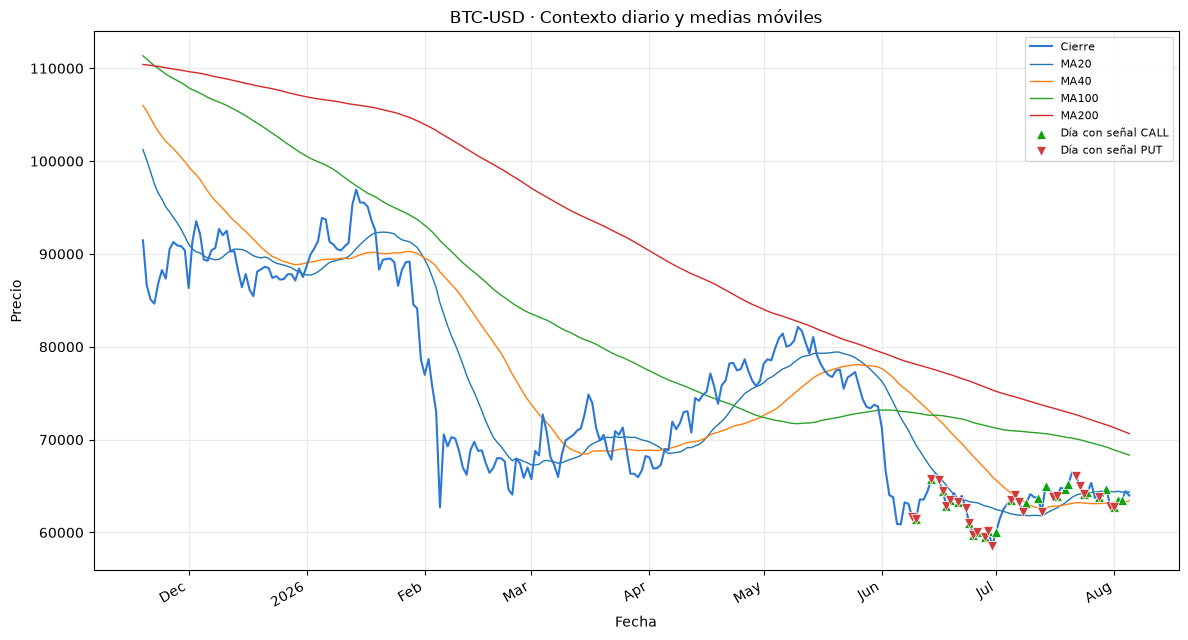

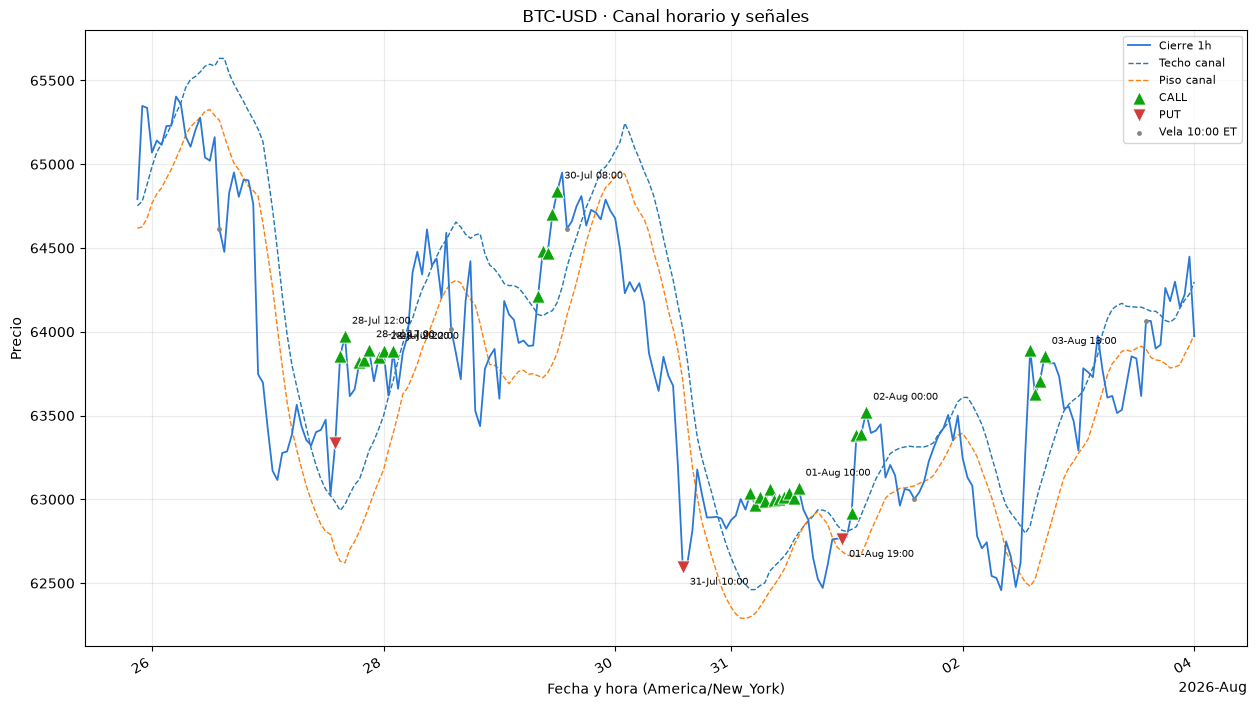

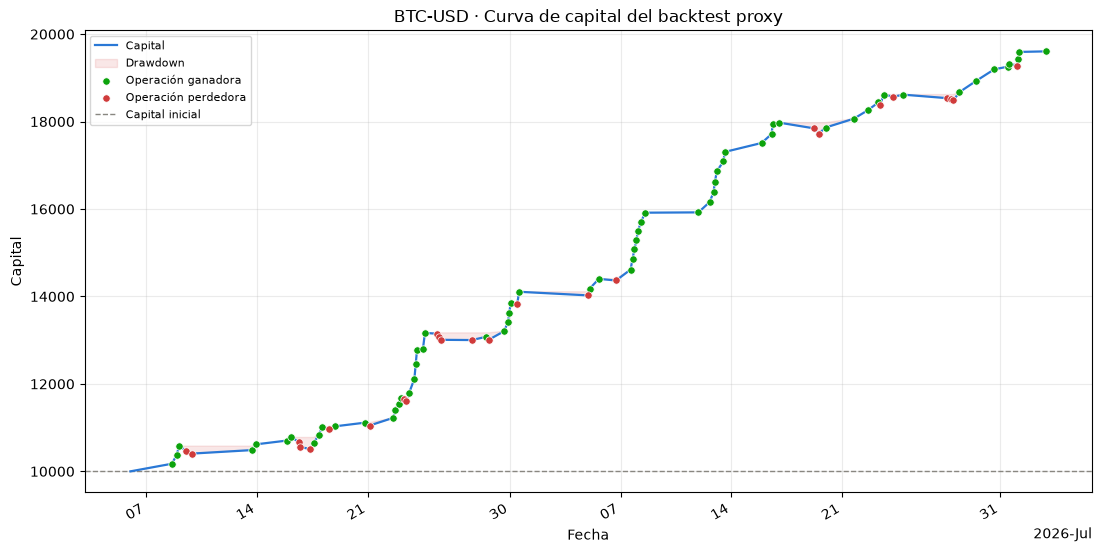

In [8]:
def format_datetime_axis(ax: plt.Axes, tz) -> None:
    """
    Eje de fecha/hora legible: ubica los ticks automáticamente y los formatea
    de forma 'concisa' (fecha una sola vez, luego solo hora:minuto) en vez de
    rotar etiquetas de día completo. También evita el efecto de
    `fig.autofmt_xdate()`, que en figuras con varios subplots independientes
    oculta las etiquetas de todos los paneles salvo el de la última fila.
    """
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator, tz=tz)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha("right")

def plot_daily_context(
    daily_df: pd.DataFrame,
    signal_df: pd.DataFrame,
    ticker: str,
    bars: int = 260,
) -> None:
    view = daily_df.tail(bars)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(
        view.index,
        view["Close"],
        linewidth=1.5,
        color=PRICE_COLOR,
        label="Cierre",
        zorder=3,
    )

    for window in [20, 40, 100, 200]:
        column = f"MA{window}"
        if column in view.columns:
            ax.plot(
                view.index,
                view[column],
                linewidth=1.0,
                label=column,
                zorder=2,
            )

    # Marca los días con al menos una señal CALL/PUT activa (la ventana
    # intradía de Yahoo Finance es limitada, así que esto solo cubre los
    # últimos `intraday_period` días, no todo el histórico diario mostrado).
    if "SessionDate" in signal_df.columns:
        active = signal_df.loc[signal_df["Signal"].ne(0), ["SessionDate", "Signal"]]
        has_call = set(active.loc[active["Signal"].eq(1), "SessionDate"])
        has_put = set(active.loc[active["Signal"].eq(-1), "SessionDate"])
        view_dates = pd.Series(view.index.date, index=view.index)

        call_days = view.index[view_dates.isin(has_call)]
        put_days = view.index[view_dates.isin(has_put)]

        ax.scatter(
            call_days, view.loc[call_days, "Close"],
            marker="^", s=50, color=ZONE_COLOR_GOOD,
            edgecolors="white", linewidths=0.5, zorder=5,
            label="Día con señal CALL",
        )
        ax.scatter(
            put_days, view.loc[put_days, "Close"],
            marker="v", s=50, color=ZONE_COLOR_CRITICAL,
            edgecolors="white", linewidths=0.5, zorder=5,
            label="Día con señal PUT",
        )

    ax.set_title(f"{ticker} · Contexto diario y medias móviles")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    format_datetime_axis(ax, view.index.tz)
    plt.show()

def plot_hourly_signals(
    signal_df: pd.DataFrame,
    ticker: str,
    bars: int = 220,
    max_time_labels: int = 10,
) -> None:
    view = signal_df.tail(bars).copy()
    calls = view["Signal"].eq(1)
    puts = view["Signal"].eq(-1)

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.plot(
        view.index,
        view["Close"],
        linewidth=1.3,
        color=PRICE_COLOR,
        label="Cierre 1h",
        zorder=3,
    )
    ax.plot(
        view.index,
        view["ChannelUpper"],
        linestyle="--",
        linewidth=1.0,
        label="Techo canal",
        zorder=2,
    )
    ax.plot(
        view.index,
        view["ChannelLower"],
        linestyle="--",
        linewidth=1.0,
        label="Piso canal",
        zorder=2,
    )

    ax.scatter(
        view.index[calls],
        view.loc[calls, "Close"],
        marker="^",
        s=90,
        color=ZONE_COLOR_GOOD,
        edgecolors="white",
        linewidths=0.6,
        label="CALL",
        zorder=5,
    )
    ax.scatter(
        view.index[puts],
        view.loc[puts, "Close"],
        marker="v",
        s=90,
        color=ZONE_COLOR_CRITICAL,
        edgecolors="white",
        linewidths=0.6,
        label="PUT",
        zorder=5,
    )

    # Hora exacta solo en la última vela de cada racha consecutiva de la
    # misma estrategia (una regla como 'Ruptura del canal bajista' puede
    # permanecer activa varias velas seguidas) y, si aun así hay muchas,
    # limitado a las `max_time_labels` más recientes para no saturar el eje.
    signal_mask = view["Signal"].ne(0).to_numpy()
    strategy_arr = view["Strategy"].to_numpy()
    signal_arr = view["Signal"].to_numpy()
    n = len(view)
    run_end = np.zeros(n, dtype=bool)
    for i in np.flatnonzero(signal_mask):
        run_end[i] = (
            i == n - 1
            or signal_arr[i + 1] != signal_arr[i]
            or strategy_arr[i + 1] != strategy_arr[i]
        )
    labeled_idx = view.index[run_end][-max_time_labels:]

    for ts in labeled_idx:
        row = view.loc[ts]
        is_call = row["Signal"] == 1
        ax.annotate(
            ts.strftime("%d-%b %H:%M"),
            xy=(ts, row["Close"]),
            xytext=(5, 9 if is_call else -13),
            textcoords="offset points",
            fontsize=7,
            color="#0b0b0b",
            zorder=6,
        )

    first_candle = view["IsFirstCandle"]
    ax.scatter(
        view.index[first_candle],
        view.loc[first_candle, "Close"],
        marker=".",
        s=25,
        color=GRID_COLOR,
        label=f"Vela {CFG.first_candle_hour:02d}:00 ET",
        zorder=4,
    )

    ax.set_title(f"{ticker} · Canal horario y señales")
    ax.set_xlabel(f"Fecha y hora ({CFG.timezone})")
    ax.set_ylabel("Precio")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    format_datetime_axis(ax, view.index.tz)
    plt.show()

def plot_equity_curve(
    curve: pd.DataFrame,
    trades_df: pd.DataFrame,
    ticker: str,
) -> None:
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(
        curve.index,
        curve["Equity"],
        linewidth=1.6,
        color=PRICE_COLOR,
        label="Capital",
        zorder=3,
    )

    running_max = curve["Equity"].cummax()
    ax.fill_between(
        curve.index,
        curve["Equity"],
        running_max,
        where=curve["Equity"].lt(running_max),
        color=ZONE_COLOR_CRITICAL,
        alpha=0.12,
        interpolate=True,
        label="Drawdown",
        zorder=1,
    )

    if not trades_df.empty:
        wins = trades_df["NetPnL"] > 0
        ax.scatter(
            trades_df.loc[wins, "ExitTime"], trades_df.loc[wins, "Equity"],
            marker="o", s=28, color=ZONE_COLOR_GOOD,
            edgecolors="white", linewidths=0.5, zorder=5,
            label="Operación ganadora",
        )
        ax.scatter(
            trades_df.loc[~wins, "ExitTime"], trades_df.loc[~wins, "Equity"],
            marker="o", s=28, color=ZONE_COLOR_CRITICAL,
            edgecolors="white", linewidths=0.5, zorder=5,
            label="Operación perdedora",
        )

    ax.axhline(
        CFG.initial_capital,
        linestyle="--",
        linewidth=1.0,
        color=GRID_COLOR,
        label="Capital inicial",
        zorder=2,
    )
    ax.set_title(
        f"{ticker} · Curva de capital del backtest proxy"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Capital")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    format_datetime_axis(ax, curve.index.tz)
    plt.show()

plot_daily_context(daily, signals, CFG.ticker)
plot_hourly_signals(signals, CFG.ticker)
plot_equity_curve(equity_curve, trades, CFG.ticker)


## 8. Escáner de varios activos

Esta función analiza una lista y devuelve:

- Última señal detectada.
- Fecha y hora.
- Estrategia activada.
- Cierre de referencia.
- Gap.
- Vencimiento orientativo cuando aplica.
- Antigüedad de la señal.

La descarga de muchos activos puede tardar varios minutos y Yahoo Finance puede limitar temporalmente las solicitudes.


In [9]:
def analyze_one_asset(
    asset_key: str,
    base_cfg: StrategyConfig,
) -> Dict[str, object]:
    local_cfg = StrategyConfig(**{
        **asdict(base_cfg),
        "asset": asset_key,
        "custom_ticker": None,
    })

    daily_data, hourly_data = download_market_data(
        ticker=local_cfg.ticker,
        daily_period=local_cfg.daily_period,
        intraday_period=local_cfg.intraday_period,
        raw_intraday_interval=local_cfg.raw_intraday_interval,
        timezone=local_cfg.timezone,
    )
    daily_data = add_moving_averages(
        daily_data,
        local_cfg.ma_windows,
    )
    hourly_data = add_atr(
        hourly_data,
        local_cfg.atr_window,
    )
    hourly_data = rolling_linear_channel(
        hourly_data,
        local_cfg.hourly_channel_lookback,
    )
    signal_data = build_signals(
        daily_data,
        hourly_data,
        local_cfg,
    )
    active = signal_data.loc[signal_data["Signal"].ne(0)]

    if active.empty:
        return {
            "Activo": asset_key,
            "Ticker": local_cfg.ticker,
            "Señal": "Sin señal",
            "Fecha": pd.NaT,
            "Estrategia": "",
            "Cierre": np.nan,
            "GapPct": np.nan,
            "Vencimiento": "",
            "Horas desde señal": np.nan,
        }

    timestamp = active.index[-1]
    row = active.iloc[-1]
    now = pd.Timestamp.now(tz=local_cfg.timezone)
    hours_old = (
        now - timestamp
    ).total_seconds() / 3600.0

    return {
        "Activo": asset_key,
        "Ticker": local_cfg.ticker,
        "Señal": (
            "CALL"
            if int(row["Signal"]) == 1
            else "PUT"
        ),
        "Fecha": timestamp,
        "Estrategia": row["Strategy"],
        "Cierre": float(row["Close"]),
        "GapPct": (
            float(row["GapPct"])
            if np.isfinite(row["GapPct"])
            else np.nan
        ),
        "Vencimiento": expiry_suggestion(
            timestamp,
            bool(local_cfg.asset_meta.get("opciones", False)),
        ),
        "Horas desde señal": hours_old,
    }

def scan_assets(
    assets: List[str],
    base_cfg: StrategyConfig = CFG,
) -> pd.DataFrame:
    rows = []

    for asset in assets:
        try:
            print(f"Analizando {asset}...")
            rows.append(
                analyze_one_asset(asset, base_cfg)
            )
        except Exception as exc:
            rows.append({
                "Activo": asset,
                "Ticker": ASSETS.get(
                    asset,
                    {},
                ).get("ticker", asset),
                "Señal": "Error",
                "Fecha": pd.NaT,
                "Estrategia": str(exc),
                "Cierre": np.nan,
                "GapPct": np.nan,
                "Vencimiento": "",
                "Horas desde señal": np.nan,
            })

    return pd.DataFrame(rows).sort_values(
        ["Señal", "Horas desde señal"],
        na_position="last",
    )

WATCHLIST = [
    "ORO",
    "PLATA",
    "EUR_USD",
    "BTC",
    "ETH",
    "TESLA",
    "APPLE",
    "SPY",
    "QQQ",
]

# Descomenta para ejecutar el escáner completo:
# scan_results = scan_assets(WATCHLIST)
# display(scan_results)


## 9. Cómo modificar o mejorar el sistema

Parámetros más importantes:

```python
CFG = StrategyConfig(
    asset="TESLA",
    first_candle_hour=10,
    hourly_channel_lookback=30,
    gap_threshold=0.001,
    strong_floor_tolerance=0.012,
    risk_per_trade=0.02,
    stop_atr=1.5,
    target_atr=2.5,
)
```

Para un ticker no incluido:

```python
CFG = StrategyConfig(
    asset="PERSONALIZADO",
    custom_ticker="NVDA",
)
```

### Limitaciones

- Los gaps diarios suelen ser más informativos en acciones y ETF que en mercados 24/7.
- En forex, criptomonedas y algunos futuros, el “día” depende de la zona horaria y del proveedor.
- Yahoo Finance no proporciona una base histórica completa de primas de opciones.
- Este backtest no contempla deslizamiento variable, asignación, ejercicio anticipado, volatilidad implícita ni *theta*.
- Antes de usar dinero real, valida cada activo fuera de muestra y en una cuenta demo.

### Fuentes técnicas

- Resumen de estrategias: PDF adjunto por el usuario.
- Datos: documentación de `yfinance.download`.
- Gráficas: API de `matplotlib.pyplot`.


## 10. Zonas de entrada potencial: profit, stop loss y probabilidad histórica (15 min y 1 h)

Esta sección agrega un gráfico enfocado en la operativa: para las señales CALL/PUT
más recientes marca la **zona de entrada**, el **precio objetivo (profit)**, el
**stop loss** y una **probabilidad histórica** de que el objetivo se alcance antes
que el stop, en dos temporalidades de proyección: **15 minutos** y **1 hora**.

Pasos:

1. Se reconstruye el mismo motor de reglas de la sección 4 (`build_signals`) sobre
   velas de 15 minutos, además de las velas horarias ya calculadas.
2. Se corre el backtest proxy (sección 6) por separado en cada temporalidad.
3. Por cada `Strategy` (p. ej. *"CALL · Ruptura del canal bajista"*) se mide qué
   porcentaje histórico de operaciones cerró por **Objetivo ATR** frente a
   **Stop ATR** — esa es la "probabilidad" mostrada en el gráfico.
4. Se recalculan entrada/objetivo/stop de las señales más recientes con la misma
   fórmula del backtest, incluida la última si todavía no tiene vela siguiente
   confirmada (se marca como **pendiente**).

Cada entrada marcada en el gráfico muestra, además de la dirección y la
probabilidad, la **hora exacta de entrada** y la hora en que **"vence"** (el
horizonte máximo `cfg.max_hold_bars`, tras el cual el backtest cierra la
posición a mercado si no se tocó antes el objetivo, el stop o una vela
contraria). El eje de fecha/hora se dibuja por separado y con detalle de
hora:minuto en cada uno de los dos paneles (15 min y 1 h), en vez de una
rotación genérica que antes dejaba sin etiquetas visibles al panel superior.

> **Importante:** la probabilidad es una frecuencia histórica del propio backtest
> (con su ATR, comisiones y reglas de salida configuradas en `CFG`), no una
> predicción ni una garantía. Con pocas operaciones (`n` bajo en la tabla) la
> estimación es poco confiable. El lookback del canal en 15 min se escala x4
> respecto al de 1 hora para cubrir una ventana de tiempo real similar. El
> horizonte "vence" se aproxima con el espaciado mediano entre velas, así que en
> activos con huecos de sesión (acciones, forex) es una referencia, no un cálculo
> exacto por barra.


In [10]:
def build_intraday_signals(
    ticker: str,
    daily_with_ma: pd.DataFrame,
    cfg: StrategyConfig,
    raw_interval: str,
    resample_rule: str,
    channel_lookback: int,
) -> pd.DataFrame:
    """Reconstruye el motor de señales de la sección 4 sobre otra temporalidad intradía."""
    _, bars_raw = download_market_data(
        ticker=ticker,
        daily_period=cfg.daily_period,
        intraday_period=cfg.intraday_period,
        raw_intraday_interval=raw_interval,
        timezone=cfg.timezone,
        resample_rule=resample_rule,
    )
    bars = add_atr(bars_raw, cfg.atr_window)
    bars = rolling_linear_channel(bars, channel_lookback)
    return build_signals(daily_with_ma, bars, cfg)

TIMEFRAMES: Dict[str, Dict[str, object]] = {
    "15 min": {
        "channel_lookback": CFG.hourly_channel_lookback * 4,
        "bars_to_plot": 180,
    },
    "1 hora": {
        "channel_lookback": CFG.hourly_channel_lookback,
        "bars_to_plot": 140,
    },
}

signals_15m = build_intraday_signals(
    ticker=CFG.ticker,
    daily_with_ma=daily,
    cfg=CFG,
    raw_interval="15m",
    resample_rule="15min",
    channel_lookback=TIMEFRAMES["15 min"]["channel_lookback"],
)

print(f"{CFG.ticker}: {len(signals_15m):,} velas de 15 min procesadas.")
display(
    signals_15m.loc[
        signals_15m["Signal"].ne(0),
        ["Open", "High", "Low", "Close", "GapPct", "Signal", "Strategy"],
    ].tail(10)
)


BTC-USD: 5,666 velas de 15 min procesadas.


,Open,High,Low,Close,GapPct,Signal,Strategy
Datetime,,,,,,,
2026-08-03 11:45:00-04:00,63485.441406,63765.011719,63579.171875,63627.730469,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 12:00:00-04:00,63485.441406,63840.671875,63591.148438,63737.601562,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 12:15:00-04:00,63485.441406,63883.570312,63735.058594,63844.628906,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 12:30:00-04:00,63485.441406,63833.589844,63644.800781,63696.628906,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 12:45:00-04:00,63485.441406,63817.890625,63676.800781,63707.238281,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 13:00:00-04:00,63485.441406,63799.878906,63650.000000,63791.101562,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 13:15:00-04:00,63485.441406,63994.859375,63749.558594,63760.031250,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 13:30:00-04:00,63485.441406,63869.351562,63728.730469,63834.519531,0.000054,1,CALL · Ruptura del canal bajista
2026-08-03 13:45:00-04:00,63485.441406,63902.679688,63807.480469,63852.750000,0.000054,1,CALL · Ruptura del canal bajista


In [11]:
def strategy_probability_table(trades_df: pd.DataFrame) -> pd.DataFrame:
    """
    Frecuencia histórica de cada motivo de salida por estrategia en el backtest
    proxy. 'Objetivo %' es la probabilidad empírica —no una garantía— de que el
    precio alcance el objetivo ATR antes que el stop.
    """
    columns = ["Operaciones", "Objetivo %", "Stop %", "Otro %", "Tasa de acierto %"]
    if trades_df.empty:
        return pd.DataFrame(columns=columns)

    outcome = np.select(
        [
            trades_df["ExitReason"].eq("Objetivo ATR"),
            trades_df["ExitReason"].eq("Stop ATR"),
        ],
        ["Objetivo", "Stop"],
        default="Otro",
    )
    shares = (
        pd.Series(outcome, index=trades_df.index, name="Resultado")
        .groupby(trades_df["Strategy"])
        .value_counts(normalize=True)
        .unstack(fill_value=0.0)
        .reindex(columns=["Objetivo", "Stop", "Otro"], fill_value=0.0)
        .mul(100.0)
        .round(1)
        .rename(columns={"Objetivo": "Objetivo %", "Stop": "Stop %", "Otro": "Otro %"})
    )
    counts = trades_df.groupby("Strategy").size().rename("Operaciones")
    hit_rate = (
        (trades_df["NetPnL"] > 0)
        .groupby(trades_df["Strategy"])
        .mean()
        .mul(100.0)
        .round(1)
        .rename("Tasa de acierto %")
    )
    return pd.concat([counts, shares, hit_rate], axis=1)[columns]

trades_15m, equity_curve_15m, metrics_15m = backtest_underlying(signals_15m, CFG)

prob_table_15m = strategy_probability_table(trades_15m)
prob_table_1h = strategy_probability_table(trades)  # `trades` es el backtest horario de la sección 6

print("Probabilidad histórica por estrategia · 15 min:")
display(prob_table_15m)
print("Probabilidad histórica por estrategia · 1 hora:")
display(prob_table_1h)


Probabilidad histórica por estrategia · 15 min:


,Operaciones,Objetivo %,Stop %,Otro %,Tasa de acierto %
Strategy,,,,,
CALL · Ruptura del canal bajista,197,77.2,1.5,21.3,84.8
PUT · Canal bajista,152,90.1,2.6,7.2,92.8
PUT · Primera vela roja,26,80.8,7.7,11.5,84.6


Probabilidad histórica por estrategia · 1 hora:


,Operaciones,Objetivo %,Stop %,Otro %,Tasa de acierto %
Strategy,,,,,
CALL · Ruptura del canal bajista,37,32.4,5.4,62.2,59.5
PUT · Canal bajista,27,81.5,3.7,14.8,85.2
PUT · Primera vela roja,23,65.2,8.7,26.1,73.9


In [12]:
ZONE_COLUMNS = [
    "SignalTime", "EntryTime", "Direction", "Strategy",
    "Entry", "Stop", "Target", "Pending", "RunEnd", "Deadline",
]

def compute_zone_levels(signal_df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    """
    Recalcula entrada/objetivo/stop con la misma lógica que `backtest_underlying`
    (entrada en la apertura de la vela siguiente al cierre de la señal), para
    poder dibujar también la señal más reciente aunque todavía no tenga una vela
    siguiente confirmada (se marca como 'pendiente').

    `Deadline` es el horizonte máximo de la operación: `cfg.max_hold_bars` velas
    después de la entrada. Si el precio no toca el objetivo, el stop, o cierra
    con una vela contraria antes, el backtest cierra la posición a mercado en
    ese punto (ver sección 6, `backtest_underlying`). Se aproxima con la
    mediana del espaciado entre velas, así que en activos con huecos de sesión
    (acciones, forex) es una referencia, no un cálculo exacto por barra.

    `RunEnd` marca solo la última vela de cada racha consecutiva de señales
    idénticas (misma Strategy, posiciones de vela contiguas) — reglas como
    'Ruptura del canal bajista' pueden permanecer activas varias velas seguidas,
    y esto evita amontonar marcadores/etiquetas repetidas al graficar.
    """
    atr_column = f"ATR{cfg.atr_window}"
    signal_positions = np.flatnonzero(signal_df["Signal"].to_numpy() != 0)
    rows: List[Dict[str, object]] = []

    bar_span = pd.Series(signal_df.index).diff().dropna().median()
    if pd.isna(bar_span) or bar_span <= pd.Timedelta(0):
        bar_span = pd.Timedelta(minutes=15)

    for i in signal_positions:
        atr = signal_df.iloc[i].get(atr_column, np.nan)
        if not np.isfinite(atr) or atr <= 0:
            continue

        direction = int(signal_df.iloc[i]["Signal"])
        pending = (i + 1) >= len(signal_df)

        if pending:
            entry_price = float(signal_df.iloc[i]["Close"])
            entry_time = signal_df.index[i]
        else:
            entry_price = float(signal_df.iloc[i + 1]["Open"])
            entry_time = signal_df.index[i + 1]

        if not np.isfinite(entry_price) or entry_price <= 0:
            continue

        stop_distance = max(float(atr) * cfg.stop_atr, entry_price * 0.001)
        target_distance = max(float(atr) * cfg.target_atr, entry_price * 0.001)

        if direction == 1:
            stop_price = entry_price - stop_distance
            target_price = entry_price + target_distance
        else:
            stop_price = entry_price + stop_distance
            target_price = entry_price - target_distance

        strategy = signal_df.iloc[i]["Strategy"]
        rows.append({
            "SignalTime": signal_df.index[i],
            "EntryTime": entry_time,
            "Direction": "CALL" if direction == 1 else "PUT",
            "Strategy": strategy,
            "Entry": entry_price,
            "Stop": stop_price,
            "Target": target_price,
            "Pending": pending,
            "Deadline": entry_time + cfg.max_hold_bars * bar_span,
            "_Pos": i,
        })

    for idx in range(len(rows) - 1):
        current, nxt = rows[idx], rows[idx + 1]
        same_run = (
            nxt["_Pos"] == current["_Pos"] + 1
            and nxt["Strategy"] == current["Strategy"]
        )
        current["RunEnd"] = not same_run
    if rows:
        rows[-1]["RunEnd"] = True

    return pd.DataFrame(rows, columns=ZONE_COLUMNS)

def attach_probability(zones_df: pd.DataFrame, prob_table: pd.DataFrame) -> pd.DataFrame:
    zones_df = zones_df.copy()
    if zones_df.empty:
        zones_df["ProbObjetivo"] = np.nan
        return zones_df
    return zones_df.merge(
        prob_table[["Objetivo %"]].rename(columns={"Objetivo %": "ProbObjetivo"}),
        left_on="Strategy",
        right_index=True,
        how="left",
    )

zones_15m = attach_probability(compute_zone_levels(signals_15m, CFG), prob_table_15m)
zones_1h = attach_probability(compute_zone_levels(signals, CFG), prob_table_1h)

print(f"Zonas de entrada detectadas → 15 min: {len(zones_15m)} | 1 hora: {len(zones_1h)}")
display(zones_15m.loc[zones_15m["RunEnd"]].tail(8))
display(zones_1h.loc[zones_1h["RunEnd"]].tail(8))


Zonas de entrada detectadas → 15 min: 849 | 1 hora: 212


,SignalTime,EntryTime,Direction,Strategy,Entry,Stop,Target,Pending,RunEnd,Deadline,ProbObjetivo
812,2026-08-01 11:30:00-04:00,2026-08-01 11:45:00-04:00,CALL,CALL · Ruptura del canal bajista,62813.664062,62750.850398,62890.635324,False,True,2026-08-01 13:45:00-04:00,77.2
813,2026-08-01 18:30:00-04:00,2026-08-01 18:45:00-04:00,PUT,PUT · Canal bajista,62813.664062,62934.375977,62612.477539,False,True,2026-08-01 20:45:00-04:00,90.1
814,2026-08-01 19:45:00-04:00,2026-08-01 20:00:00-04:00,PUT,PUT · Canal bajista,62813.664062,62904.383092,62662.465681,False,True,2026-08-01 22:00:00-04:00,90.1
815,2026-08-01 20:00:00-04:00,2026-08-01 20:15:00-04:00,CALL,CALL · Ruptura del canal bajista,62813.664062,62714.244699,62979.363002,False,True,2026-08-01 22:15:00-04:00,77.2
817,2026-08-01 20:45:00-04:00,2026-08-01 21:00:00-04:00,PUT,PUT · Canal bajista,62813.664062,62901.618304,62667.073661,False,True,2026-08-01 23:00:00-04:00,90.1
831,2026-08-02 00:15:00-04:00,2026-08-02 00:30:00-04:00,CALL,CALL · Ruptura del canal bajista,62763.445312,62563.401646,63096.851423,False,True,2026-08-02 02:30:00-04:00,77.2
832,2026-08-03 10:00:00-04:00,2026-08-03 10:15:00-04:00,PUT,PUT · Primera vela roja,63485.441406,63795.553432,62968.588030,False,True,2026-08-03 12:15:00-04:00,80.8
848,2026-08-03 14:00:00-04:00,2026-08-03 14:15:00-04:00,CALL,CALL · Ruptura del canal bajista,63485.441406,63205.890206,63951.360073,False,True,2026-08-03 16:15:00-04:00,77.2


,SignalTime,EntryTime,Direction,Strategy,Entry,Stop,Target,Pending,RunEnd,Deadline,ProbObjetivo
184,2026-07-28 20:00:00-04:00,2026-07-28 21:00:00-04:00,CALL,CALL · Ruptura del canal bajista,63723.488281,63180.302037,64628.798689,False,True,2026-07-29 05:00:00-04:00,32.4
185,2026-07-28 22:00:00-04:00,2026-07-28 23:00:00-04:00,CALL,CALL · Ruptura del canal bajista,63723.488281,63143.413923,64690.278878,False,True,2026-07-29 07:00:00-04:00,32.4
190,2026-07-30 08:00:00-04:00,2026-07-30 09:00:00-04:00,CALL,CALL · Ruptura del canal bajista,63908.625000,63485.415737,64613.973772,False,True,2026-07-30 17:00:00-04:00,32.4
191,2026-07-31 10:00:00-04:00,2026-07-31 11:00:00-04:00,PUT,PUT · Primera vela roja,64723.968750,65273.029436,63808.867606,False,True,2026-07-31 19:00:00-04:00,65.2
202,2026-08-01 10:00:00-04:00,2026-08-01 11:00:00-04:00,CALL,CALL · Ruptura del canal bajista,62813.664062,62677.724888,63040.229353,False,True,2026-08-01 19:00:00-04:00,32.4
203,2026-08-01 19:00:00-04:00,2026-08-01 20:00:00-04:00,PUT,PUT · Canal bajista,62813.664062,63040.552455,62435.516741,False,True,2026-08-02 04:00:00-04:00,81.5
207,2026-08-02 00:00:00-04:00,2026-08-02 01:00:00-04:00,CALL,CALL · Ruptura del canal bajista,62763.445312,62435.472238,63310.067104,False,True,2026-08-02 09:00:00-04:00,32.4
211,2026-08-03 13:00:00-04:00,2026-08-03 14:00:00-04:00,CALL,CALL · Ruptura del canal bajista,63485.441406,62961.129883,64359.293945,False,True,2026-08-03 22:00:00-04:00,32.4


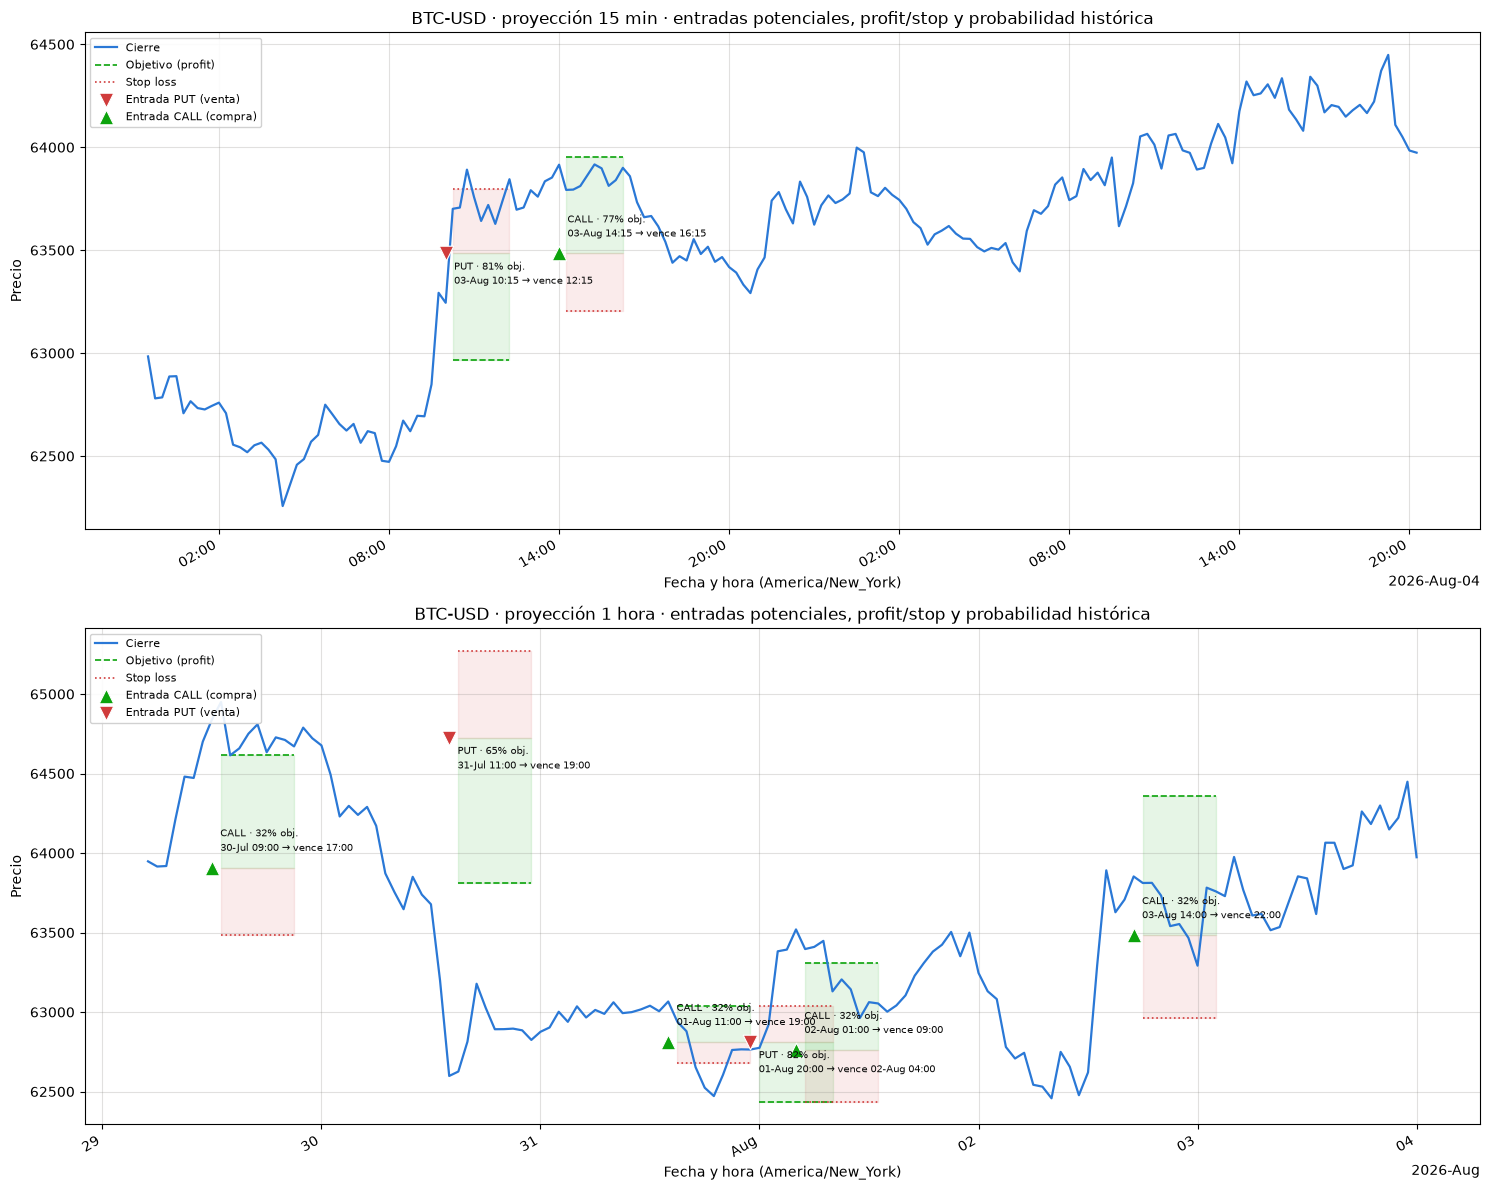

In [13]:
# La paleta (ZONE_COLOR_GOOD/CRITICAL, PRICE_COLOR, GRID_COLOR) se definió una
# sola vez en la celda de configuración (sección 1) para que las 4 gráficas del
# notebook compartan el mismo lenguaje visual: verde = objetivo/profit/CALL/
# ganadora, rojo = stop loss/drawdown/PUT/perdedora. La dirección y el
# resultado nunca dependen solo del color: cada marca añade además una forma
# distinta (▲/▼), un trazo distinto (guiones/puntos) o una etiqueta de texto.

def plot_entry_zones(
    ax: plt.Axes,
    signal_df: pd.DataFrame,
    zones_df: pd.DataFrame,
    ticker: str,
    timeframe_label: str,
    bars: int,
    max_zones: int = 6,
) -> None:
    view = signal_df.tail(bars)
    bar_span = (
        view.index[1] - view.index[0]
        if len(view) > 1
        else pd.Timedelta(minutes=15)
    )

    ax.plot(
        view.index,
        view["Close"],
        linewidth=1.6,
        color=PRICE_COLOR,
        label="Cierre",
        zorder=3,
    )

    # Solo se dibuja la última vela de cada racha consecutiva de la misma
    # estrategia (ver `RunEnd` en compute_zone_levels): evita amontonar
    # marcadores y etiquetas cuando una regla permanece activa varias velas.
    visible = zones_df[
        zones_df["SignalTime"].isin(view.index) & zones_df["RunEnd"]
    ].tail(max_zones)

    if visible.empty:
        ax.text(
            0.5, 0.5, "Sin señales recientes en esta ventana",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color=GRID_COLOR,
        )

    labeled = {"CALL": False, "PUT": False, "Objetivo": False, "Stop": False}
    used_offsets: List[Tuple[pd.Timestamp, int]] = []

    for _, zone in visible.iterrows():
        direction = zone["Direction"]
        color = ZONE_COLOR_GOOD if direction == "CALL" else ZONE_COLOR_CRITICAL
        marker = "^" if direction == "CALL" else "v"
        start = zone["EntryTime"]
        end = zone["Deadline"]

        ax.fill_between(
            [start, end], [zone["Entry"]] * 2, [zone["Target"]] * 2,
            color=ZONE_COLOR_GOOD, alpha=0.10, zorder=1,
        )
        ax.fill_between(
            [start, end], [zone["Entry"]] * 2, [zone["Stop"]] * 2,
            color=ZONE_COLOR_CRITICAL, alpha=0.10, zorder=1,
        )

        ax.hlines(
            zone["Target"], start, end,
            colors=ZONE_COLOR_GOOD, linestyles="--", linewidth=1.2,
            label=None if labeled["Objetivo"] else "Objetivo (profit)",
            zorder=2,
        )
        ax.hlines(
            zone["Stop"], start, end,
            colors=ZONE_COLOR_CRITICAL, linestyles=":", linewidth=1.2,
            label=None if labeled["Stop"] else "Stop loss",
            zorder=2,
        )
        labeled["Objetivo"] = True
        labeled["Stop"] = True

        ax.scatter(
            [zone["SignalTime"]], [zone["Entry"]],
            marker=marker, s=110, color=color,
            edgecolors="white", linewidths=0.8, zorder=5,
            label=None if labeled[direction] else (
                "Entrada CALL (compra)" if direction == "CALL" else "Entrada PUT (venta)"
            ),
        )
        labeled[direction] = True

        prob = zone["ProbObjetivo"]
        prob_text = f"{prob:.0f}% obj." if pd.notna(prob) else "sin histórico"
        tag = " · pendiente" if zone["Pending"] else ""

        entry_str = zone["EntryTime"].strftime("%d-%b %H:%M")
        deadline_str = (
            zone["Deadline"].strftime("%H:%M")
            if zone["Deadline"].date() == zone["EntryTime"].date()
            else zone["Deadline"].strftime("%d-%b %H:%M")
        )

        # Alterna el desplazamiento vertical de la etiqueta si ya se usó uno
        # muy cercano en el tiempo, para reducir choques de texto entre zonas.
        base_offset = 12 if direction == "CALL" else -22
        offset = base_offset
        step = 0
        while any(
            abs((zone["SignalTime"] - t).total_seconds()) < (3 * bar_span).total_seconds()
            and o == offset
            for t, o in used_offsets
        ):
            step += 1
            offset = base_offset + (step if direction == "CALL" else -step) * 20
        used_offsets.append((zone["SignalTime"], offset))

        ax.annotate(
            f"{direction}{tag} · {prob_text}\n{entry_str} → vence {deadline_str}",
            xy=(zone["SignalTime"], zone["Entry"]),
            xytext=(6, offset),
            textcoords="offset points",
            fontsize=7.5,
            color="#0b0b0b",
            zorder=6,
            linespacing=1.4,
        )

    ax.set_title(
        f"{ticker} · {timeframe_label} · entradas potenciales, profit/stop y probabilidad histórica"
    )
    ax.set_xlabel(f"Fecha y hora ({CFG.timezone})")
    ax.set_ylabel("Precio")
    ax.grid(alpha=0.25, color=GRID_COLOR)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    format_datetime_axis(ax, view.index.tz)

fig, (ax_15m, ax_1h) = plt.subplots(2, 1, figsize=(15, 12))

plot_entry_zones(
    ax_15m, signals_15m, zones_15m, CFG.ticker, "proyección 15 min",
    bars=TIMEFRAMES["15 min"]["bars_to_plot"],
)
plot_entry_zones(
    ax_1h, signals, zones_1h, CFG.ticker, "proyección 1 hora",
    bars=TIMEFRAMES["1 hora"]["bars_to_plot"],
)

plt.tight_layout()
plt.show()


## 11. Proyección de estructura semanal (canal extendido + Fibonacci + entrada/TP/SL)

Esta sección construye, con velas **semanales**, el equivalente cuantificable
del boceto típico de "hacia dónde podría ir el precio" que un analista dibuja
a mano sobre un gráfico (picos y valles proyectados hacia la derecha). En vez
de trazar una ruta arbitraria, se calculan tres piezas objetivas y
reproducibles a partir de los datos:

1. **Swings (fractales)**: un máximo o mínimo local se confirma cuando es el
   extremo estricto dentro de una ventana de `FRACTAL_WINDOW` velas a cada
   lado — igual que el resto del notebook, sin mirar al futuro.
2. **Canal de regresión extendido**: se reutiliza `rolling_linear_channel`
   (la misma función de la sección 3) sobre las velas semanales, y se
   extrapola la pendiente ajustada con las últimas `WEEKLY_CHANNEL_LOOKBACK`
   velas `PROJECTION_WEEKS` semanas hacia adelante.
3. **Niveles de Fibonacci**: retrocesos (23.6–78.6 %) y extensiones
   (27.2–100 %) medidos sobre el último tramo swing→swing confirmado.

Con esas tres piezas se arma una **idea estructural** (no una señal del motor
de reglas de las secciones 4-10): si el canal proyectado sube, se plantea un
sesgo CALL con stop bajo el último swing low confirmado (más un colchón de
ATR) y objetivo en el techo del canal proyectado a `TARGET_HORIZON_WEEKS`
semanas; si baja, el espejo con PUT. Si el techo y el piso del canal
proyectado no coinciden en dirección, no se plantea idea direccional y solo
se muestran los niveles objetivo.

> **Importante — esto es distinto a las secciones 4-10:**
> - No hay probabilidad histórica asociada (a diferencia de la sección 10).
>   Backtestear una lectura de estructura semanal con ~2 años de velas
>   semanales dejaría muestras demasiado pequeñas para que un porcentaje
>   fuera confiable, así que deliberadamente no se inventa uno aquí.
> - El canal proyectado **extrapola la pendiente actual**, no predice: en la
>   práctica el precio suele girar antes de que la extrapolación se cumpla.
> - Los niveles de Fibonacci son una heurística ampliamente usada en análisis
>   técnico discrecional, no una ley estadística validada en este notebook.
> - Este material es educativo y no constituye asesoría financiera (ver la
>   nota inicial del notebook).


In [14]:
FRACTAL_WINDOW = 3
WEEKLY_CHANNEL_LOOKBACK = 20
PROJECTION_WEEKS = 12
TARGET_HORIZON_WEEKS = 8
WEEKLY_ATR_WINDOW = 10
STOP_BUFFER_ATR_MULT = 0.5
FIB_RETRACEMENTS = [0.236, 0.382, 0.5, 0.618, 0.786]
FIB_EXTENSIONS = [0.272, 0.618, 1.0]
FIB_COLOR = "#eb6834"  # naranja: siguiente tono de la paleta categórica tras el azul de precio

def resample_weekly(daily_df: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        daily_df[["Open", "High", "Low", "Close", "Volume"]]
        .resample("W-FRI", label="right", closed="right")
        .agg({"Open": "first", "High": "max", "Low": "min", "Close": "last", "Volume": "sum"})
        .dropna(subset=["Open", "High", "Low", "Close"])
    )
    return weekly

def find_swings(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    """
    Fractal simple (estilo Bill Williams): una vela es swing high/low si su
    High/Low es el extremo estricto dentro de una ventana de `window` velas a
    cada lado. Las últimas `window` velas del histórico no pueden confirmarse
    todavía (haría falta ver velas futuras) — igual que el resto del notebook
    evita look-ahead bias.
    """
    highs = df["High"].to_numpy(dtype=float)
    lows = df["Low"].to_numpy(dtype=float)
    n = len(df)
    swing_high = np.zeros(n, dtype=bool)
    swing_low = np.zeros(n, dtype=bool)

    for i in range(window, n - window):
        h_window = highs[i - window : i + window + 1]
        l_window = lows[i - window : i + window + 1]
        if highs[i] == h_window.max() and (h_window == highs[i]).sum() == 1:
            swing_high[i] = True
        if lows[i] == l_window.min() and (l_window == lows[i]).sum() == 1:
            swing_low[i] = True

    result = df.copy()
    result["SwingHigh"] = swing_high
    result["SwingLow"] = swing_low
    return result

weekly_raw = resample_weekly(daily)
weekly = add_atr(weekly_raw, WEEKLY_ATR_WINDOW)
weekly = rolling_linear_channel(weekly, WEEKLY_CHANNEL_LOOKBACK)
weekly = find_swings(weekly, FRACTAL_WINDOW)

swings = weekly.loc[weekly["SwingHigh"] | weekly["SwingLow"]].copy()
swings["SwingType"] = np.where(swings["SwingHigh"], "high", "low")
swings["SwingPrice"] = np.where(swings["SwingHigh"], swings["High"], swings["Low"])

print(f"{CFG.ticker}: {len(weekly):,} velas semanales, {len(swings):,} swings confirmados.")
display(weekly.tail())
display(swings[["SwingType", "SwingPrice"]].tail(8))


BTC-USD: 105 velas semanales, 20 swings confirmados.


,Open,High,Low,Close,Volume,ATR10,ChannelUpper,ChannelLower,ChannelUpperSlope,ChannelLowerSlope,SwingHigh,SwingLow
Date,,,,,,,,,,,,
2026-07-10,62545.128906,64658.968750,61275.828125,64127.140625,185800272366,5887.134375,71353.576275,65522.409930,-220.320489,-155.696097,False,False
2026-07-17,64127.968750,65507.593750,61769.000000,63899.460938,182031914092,5784.968750,69236.148314,64170.156168,-392.074007,-263.712638,False,False
2026-07-24,63899.179688,66910.062500,63686.035156,64098.496094,168130864325,5727.891016,67273.467928,62628.281394,-557.824818,-406.823628,False,False
2026-07-31,64098.492188,65658.335938,62410.867188,62813.746094,163732504330,5667.675391,66136.017229,61541.136020,-632.145160,-513.331837,False,False
2026-08-07,62813.664062,64473.601562,62226.578125,63973.640625,85796812339,5336.853516,64846.572492,60487.494079,-715.573267,-598.305698,False,False


,SwingType,SwingPrice
Date,,
2025-10-10,high,126198.070312
2025-11-21,low,80659.812500
2026-01-16,high,97860.601562
2026-02-06,low,60074.203125
2026-03-20,high,75988.398438
2026-04-03,low,64971.707031
2026-05-08,high,82792.210938
2026-07-03,low,57747.765625


In [15]:
if len(swings) < 2:
    raise ValueError(
        "No hay suficientes swings confirmados en el histórico semanal para "
        "proyectar estructura. Prueba con un daily_period más largo o un "
        "FRACTAL_WINDOW más chico."
    )

swing_a_time, swing_b_time = swings.index[-2], swings.index[-1]
swing_a_price = float(swings.loc[swing_a_time, "SwingPrice"])
swing_b_price = float(swings.loc[swing_b_time, "SwingPrice"])
leg_diff = swing_b_price - swing_a_price

fib_retracements = {pct: swing_b_price - leg_diff * pct for pct in FIB_RETRACEMENTS}
fib_extensions = {pct: swing_b_price + leg_diff * pct for pct in FIB_EXTENSIONS}

def project_channel_forward(
    channel_df: pd.DataFrame,
    lookback: int,
    projection_bars: int,
):
    """
    Extrapola el canal de regresión ya ajustado en `rolling_linear_channel`
    (sin look-ahead bias) más allá de la última vela observada, usando la
    pendiente ajustada con las últimas `lookback` velas (incluida la más
    reciente: a diferencia del ajuste histórico, aquí el objetivo es
    proyectar hacia adelante con toda la información disponible hoy).
    """
    highs = channel_df["High"].to_numpy(dtype=float)
    lows = channel_df["Low"].to_numpy(dtype=float)
    n = len(channel_df)
    x = np.arange(lookback, dtype=float)
    slope_h, intercept_h = np.polyfit(x, highs[n - lookback : n], 1)
    slope_l, intercept_l = np.polyfit(x, lows[n - lookback : n], 1)

    bar_span = pd.Series(channel_df.index).diff().dropna().median()
    future_index = pd.date_range(
        channel_df.index[-1] + bar_span, periods=projection_bars, freq=bar_span
    )
    steps = np.arange(lookback, lookback + projection_bars, dtype=float)

    projected = pd.DataFrame(
        {
            "ChannelUpperProjected": intercept_h + slope_h * steps,
            "ChannelLowerProjected": intercept_l + slope_l * steps,
        },
        index=future_index,
    )
    return projected, slope_h, slope_l

channel_projection, proj_slope_h, proj_slope_l = project_channel_forward(
    weekly, WEEKLY_CHANNEL_LOOKBACK, PROJECTION_WEEKS
)
channel_rising = proj_slope_h > 0 and proj_slope_l > 0
channel_falling = proj_slope_h < 0 and proj_slope_l < 0

def _most_recent_swing_price(swings_df: pd.DataFrame, swing_type: str) -> Optional[float]:
    matches = swings_df.loc[swings_df["SwingType"].eq(swing_type)]
    return float(matches.iloc[-1]["SwingPrice"]) if not matches.empty else None

recent_swing_low = _most_recent_swing_price(swings, "low")
recent_swing_high = _most_recent_swing_price(swings, "high")

entry_price = float(weekly["Close"].iloc[-1])
last_atr = float(weekly[f"ATR{WEEKLY_ATR_WINDOW}"].iloc[-1])
stop_buffer = STOP_BUFFER_ATR_MULT * last_atr if np.isfinite(last_atr) else 0.0
horizon_idx = min(TARGET_HORIZON_WEEKS, len(channel_projection)) - 1
horizon_ts = channel_projection.index[horizon_idx]

idea_direction: Optional[str] = None
stop_price: Optional[float] = None
target_price: Optional[float] = None

if channel_rising and recent_swing_low is not None:
    idea_direction = "CALL"
    stop_price = recent_swing_low - stop_buffer
    target_price = float(channel_projection.loc[horizon_ts, "ChannelUpperProjected"])
elif channel_falling and recent_swing_high is not None:
    idea_direction = "PUT"
    stop_price = recent_swing_high + stop_buffer
    target_price = float(channel_projection.loc[horizon_ts, "ChannelLowerProjected"])

print(
    f"Último swing confirmado: {swings.loc[swing_a_time, 'SwingType']} en "
    f"{swing_a_time:%Y-%m-%d} ({swing_a_price:,.2f}) -> "
    f"{swings.loc[swing_b_time, 'SwingType']} en {swing_b_time:%Y-%m-%d} "
    f"({swing_b_price:,.2f})"
)
print(
    f"Pendiente canal proyectado: techo {proj_slope_h:+.2f}/semana · "
    f"piso {proj_slope_l:+.2f}/semana"
)

print("\nNiveles de Fibonacci (retroceso / extensión):")
display(pd.DataFrame({
    "Tipo": ["Retroceso"] * len(fib_retracements) + ["Extensión"] * len(fib_extensions),
    "Nivel": [f"{p*100:.1f}%" for p in fib_retracements] + [f"{p*100:.1f}%" for p in fib_extensions],
    "Precio": list(fib_retracements.values()) + list(fib_extensions.values()),
}))

if idea_direction is None:
    print(
        "\nSin sesgo direccional claro: el techo y el piso del canal proyectado "
        "no coinciden en dirección, o falta un swing de referencia. Se muestran "
        "solo los niveles objetivo, sin idea de entrada/TP/SL."
    )
else:
    risk = abs(entry_price - stop_price)
    reward = abs(target_price - entry_price)
    rr = reward / risk if risk > 0 else np.nan
    print(f"\nIdea estructural: {idea_direction}")
    display(pd.DataFrame({
        "Entrada": [entry_price],
        "Stop (SL)": [stop_price],
        "Objetivo (TP)": [target_price],
        "Horizonte TP": [horizon_ts.strftime("%Y-%m-%d")],
        "Ratio riesgo:beneficio": [rr],
    }))


Último swing confirmado: high en 2026-05-08 (82,792.21) -> low en 2026-07-03 (57,747.77)
Pendiente canal proyectado: techo -770.95/semana · piso -631.06/semana

Niveles de Fibonacci (retroceso / extensión):


,Tipo,Nivel,Precio
0,Retroceso,23.6%,63658.254719
1,Retroceso,38.2%,67314.743734
2,Retroceso,50.0%,70269.988281
3,Retroceso,61.8%,73225.232828
4,Retroceso,78.6%,77432.699641
5,Extensión,27.2%,50935.676500
6,Extensión,61.8%,42270.298422
7,Extensión,100.0%,32703.320312



Idea estructural: PUT


,Entrada,Stop (SL),Objetivo (TP),Horizonte TP,Ratio riesgo:beneficio
0,63973.640625,85460.637695,55397.154564,2026-10-02,0.399148


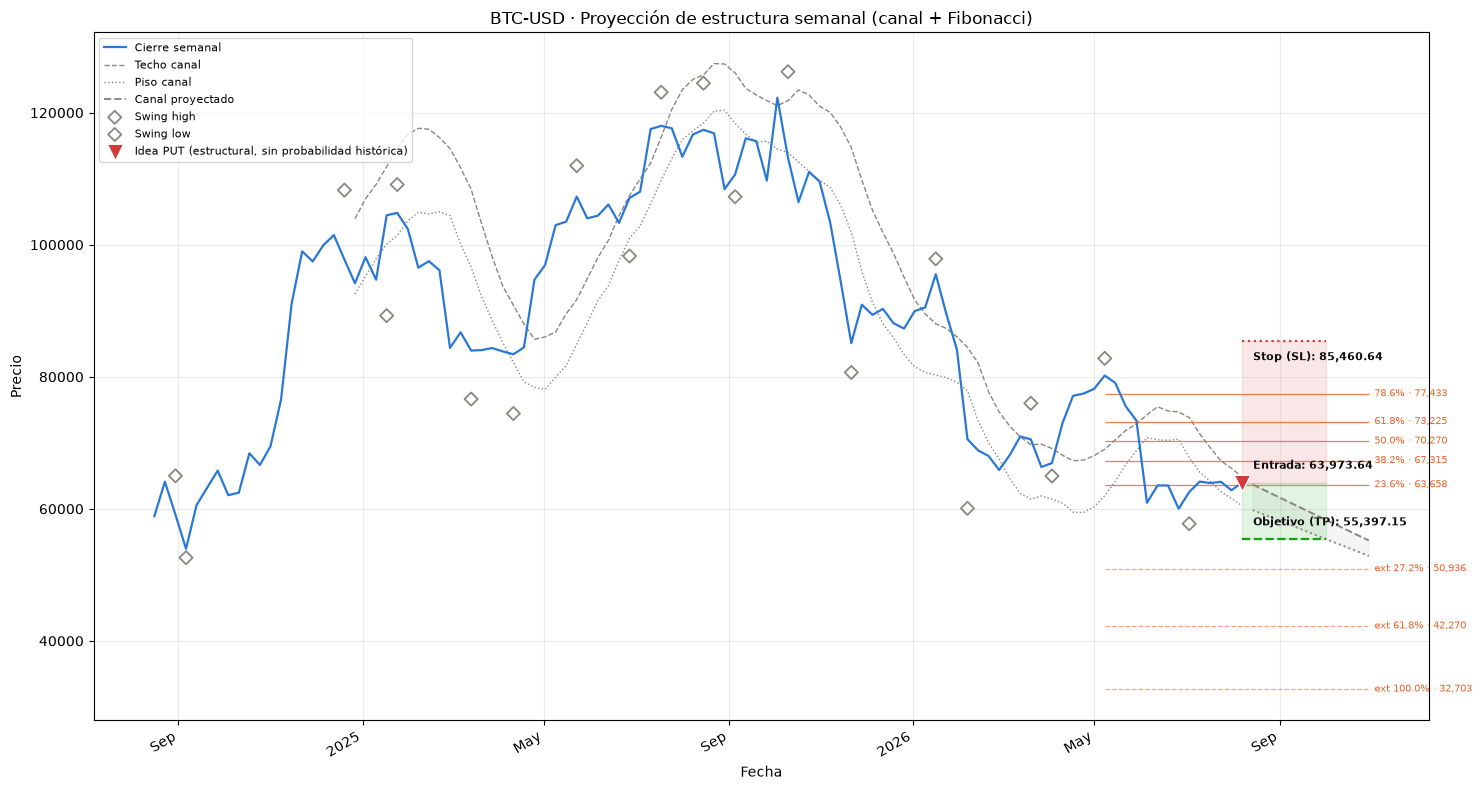

In [16]:
def plot_structure_projection(
    weekly_df: pd.DataFrame,
    swings_df: pd.DataFrame,
    channel_projection_df: pd.DataFrame,
    fib_retracements: Dict[float, float],
    fib_extensions: Dict[float, float],
    ticker: str,
    bars: int = 104,
) -> plt.Axes:
    view = weekly_df.tail(bars)

    fig, ax = plt.subplots(figsize=(15, 8))

    ax.plot(
        view.index, view["Close"], linewidth=1.6, color=PRICE_COLOR,
        label="Cierre semanal", zorder=3,
    )
    ax.plot(
        view.index, view["ChannelUpper"], linestyle="--", linewidth=1.0,
        color=GRID_COLOR, label="Techo canal", zorder=2,
    )
    ax.plot(
        view.index, view["ChannelLower"], linestyle=":", linewidth=1.0,
        color=GRID_COLOR, label="Piso canal", zorder=2,
    )
    ax.plot(
        channel_projection_df.index, channel_projection_df["ChannelUpperProjected"],
        linestyle="--", linewidth=1.4, color=GRID_COLOR, label="Canal proyectado", zorder=2,
    )
    ax.plot(
        channel_projection_df.index, channel_projection_df["ChannelLowerProjected"],
        linestyle=":", linewidth=1.4, color=GRID_COLOR, zorder=2,
    )
    ax.fill_between(
        channel_projection_df.index,
        channel_projection_df["ChannelLowerProjected"],
        channel_projection_df["ChannelUpperProjected"],
        color=GRID_COLOR, alpha=0.08, zorder=1,
    )

    swing_view = swings_df.loc[swings_df.index.isin(view.index)]
    swing_highs = swing_view.loc[swing_view["SwingType"].eq("high")]
    swing_lows = swing_view.loc[swing_view["SwingType"].eq("low")]
    ax.scatter(
        swing_highs.index, swing_highs["SwingPrice"],
        marker="D", s=45, facecolors="none", edgecolors=GRID_COLOR,
        linewidths=1.3, label="Swing high", zorder=4,
    )
    ax.scatter(
        swing_lows.index, swing_lows["SwingPrice"],
        marker="D", s=45, facecolors="none", edgecolors=GRID_COLOR,
        linewidths=1.3, label="Swing low", zorder=4,
    )

    fib_start = swings_df.index[-2]
    fib_end = channel_projection_df.index[-1]
    for pct, price in fib_retracements.items():
        ax.hlines(price, fib_start, fib_end, colors=FIB_COLOR, linestyles="-", linewidth=0.9, alpha=0.85, zorder=2)
        ax.annotate(
            f"{pct*100:.1f}% · {price:,.0f}",
            xy=(fib_end, price), xytext=(4, 0), textcoords="offset points",
            fontsize=7, color=FIB_COLOR, va="center", zorder=6,
        )
    for pct, price in fib_extensions.items():
        ax.hlines(price, fib_start, fib_end, colors=FIB_COLOR, linestyles="--", linewidth=0.9, alpha=0.6, zorder=2)
        ax.annotate(
            f"ext {pct*100:.1f}% · {price:,.0f}",
            xy=(fib_end, price), xytext=(4, 0), textcoords="offset points",
            fontsize=7, color=FIB_COLOR, va="center", zorder=6,
        )

    ax.set_title(f"{ticker} · Proyección de estructura semanal (canal + Fibonacci)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio")
    ax.grid(alpha=0.25)
    format_datetime_axis(ax, view.index.tz)
    return ax

ax = plot_structure_projection(
    weekly, swings, channel_projection, fib_retracements, fib_extensions, CFG.ticker,
)

if idea_direction is not None:
    color = ZONE_COLOR_GOOD if idea_direction == "CALL" else ZONE_COLOR_CRITICAL
    marker = "^" if idea_direction == "CALL" else "v"
    entry_time = weekly.index[-1]

    ax.fill_between(
        [entry_time, horizon_ts], [entry_price] * 2, [target_price] * 2,
        color=ZONE_COLOR_GOOD, alpha=0.12, zorder=1,
    )
    ax.fill_between(
        [entry_time, horizon_ts], [entry_price] * 2, [stop_price] * 2,
        color=ZONE_COLOR_CRITICAL, alpha=0.12, zorder=1,
    )
    ax.hlines(target_price, entry_time, horizon_ts, colors=ZONE_COLOR_GOOD, linestyles="--", linewidth=1.6, zorder=5)
    ax.hlines(stop_price, entry_time, horizon_ts, colors=ZONE_COLOR_CRITICAL, linestyles=":", linewidth=1.6, zorder=5)
    ax.scatter(
        [entry_time], [entry_price], marker=marker, s=140, color=color,
        edgecolors="white", linewidths=1.0, zorder=6,
        label=f"Idea {idea_direction} (estructural, sin probabilidad histórica)",
    )

    for price, label, dy in [
        (entry_price, "Entrada", 10),
        (target_price, "Objetivo (TP)", 10),
        (stop_price, "Stop (SL)", -14),
    ]:
        ax.annotate(
            f"{label}: {price:,.2f}",
            xy=(entry_time, price), xytext=(8, dy),
            textcoords="offset points", fontsize=8, fontweight="bold",
            color="#0b0b0b", zorder=7,
        )

ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()
